#### <span style="color:cyan">**Imports**</span>

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd

from util.data_preprocessing import *
from util.pca_plotting import *
from util.classes.PCADataset import *
from util.classes.PcaMLP import *
from util.model_eval import *
from util.model_optimization import *

from preprocessing.pipelines import build_pca_pipeline
import json
import os
import math
import numpy as np
import torch

#### <span style="color:cyan">**Data Preprocessing**</span>

Feature table (abs):
              pc_0      pc_1      pc_2      pc_3      pc_4  ...     pc_20  \
run_id                                                      ...             
run_0001 -2.217374  0.929584 -2.473297 -2.080936 -0.927886  ...  0.066816   
run_0002 -1.260568  2.485576 -1.960000 -0.449555  0.556877  ... -0.039305   
run_0003 -2.409136 -1.940734  2.035820 -0.248347  1.594865  ... -0.056005   
run_0004  4.479123 -2.959439 -0.625314 -1.815858  0.071271  ... -0.003186   
run_0005  0.363459  2.232888  1.253392 -0.963245  1.894123  ... -0.106318   

             pc_21     pc_22     pc_23     pc_24  
run_id                                            
run_0001  0.009753 -0.085810 -0.013698 -0.021518  
run_0002 -0.086259 -0.052469  0.046247 -0.002160  
run_0003  0.072037 -0.004185 -0.049986 -0.075402  
run_0004  0.069677  0.019447  0.119227 -0.036423  
run_0005 -0.176590 -0.088627  0.144734 -0.091509  

[5 rows x 25 columns]



c:\Users\robert\Code\capstone\capstone_SiC_gratings\ML_project\util\pca_plotting.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


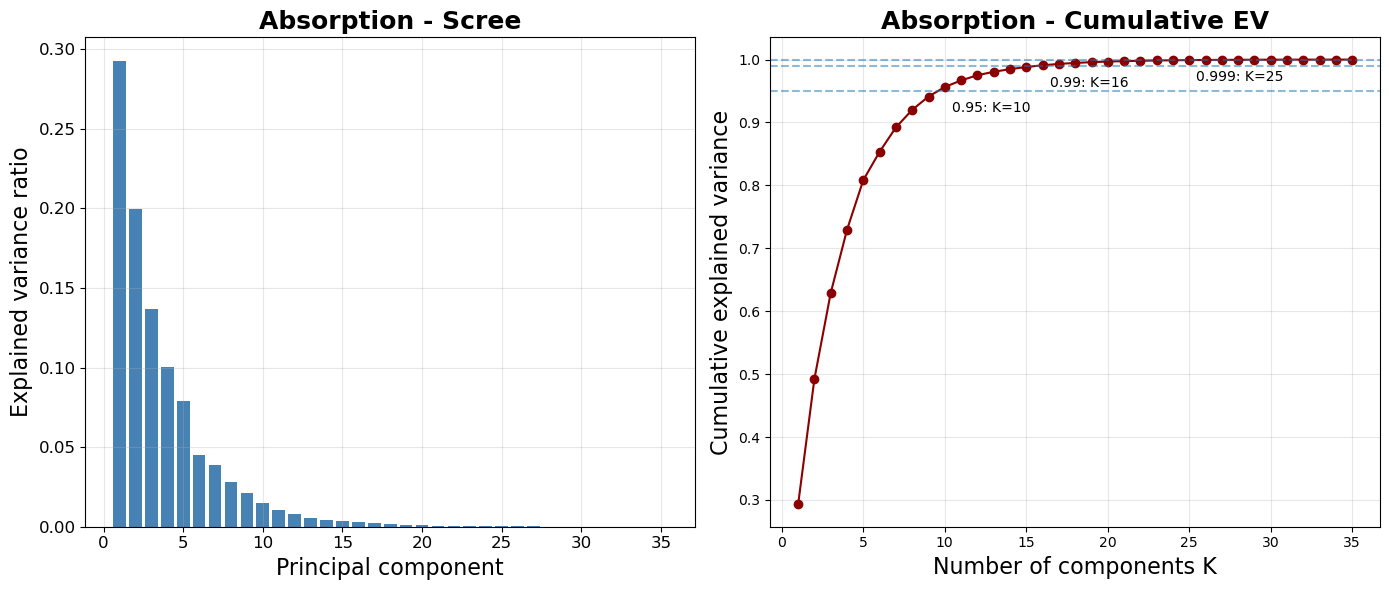

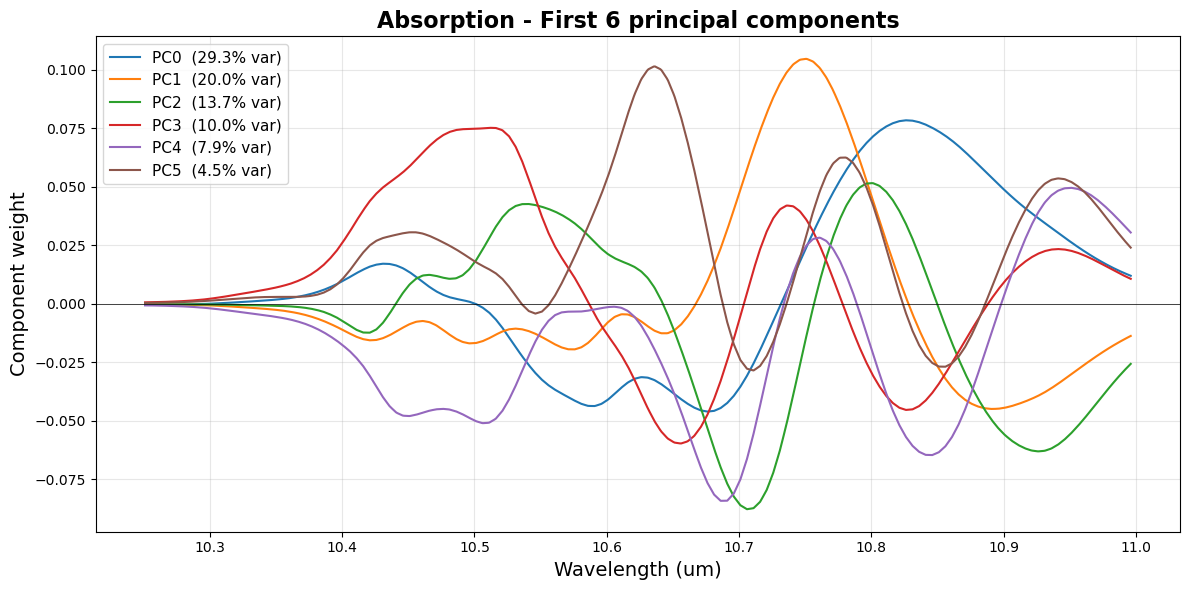

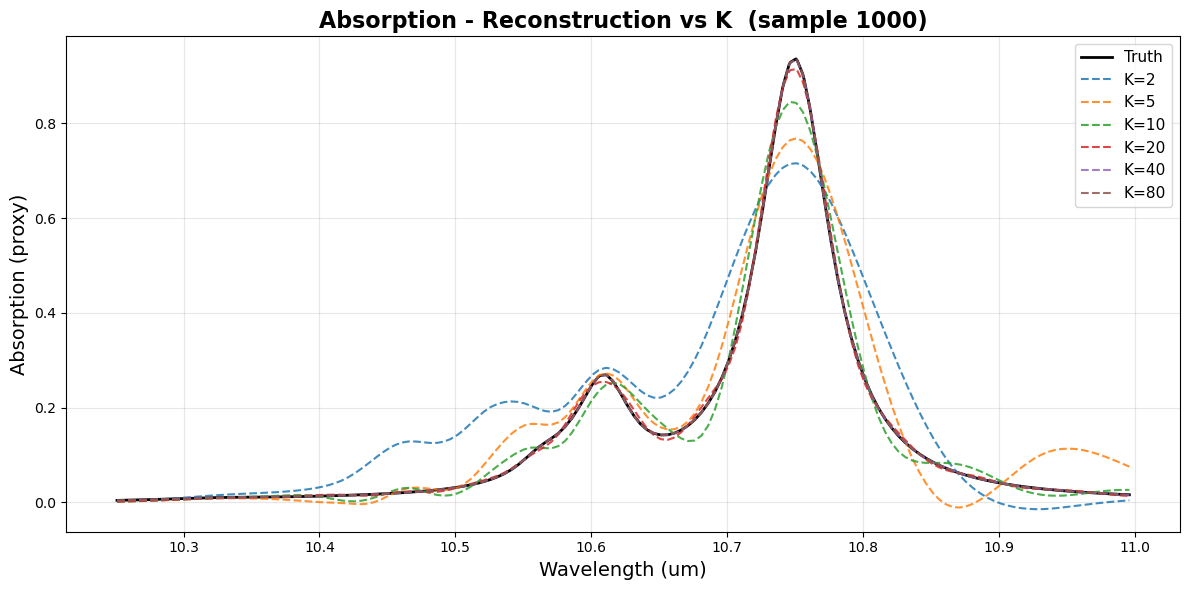

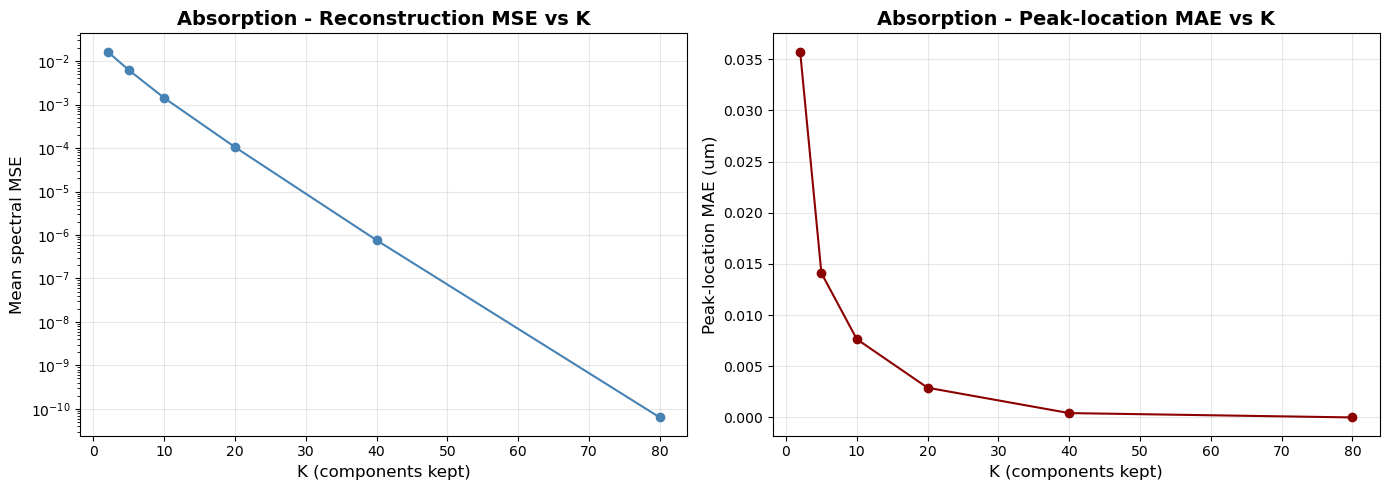

Absorption K-sweep:
  K=  2  MSE=1.661e-02  peak-MAE=0.0357 um
  K=  5  MSE=6.267e-03  peak-MAE=0.0141 um
  K= 10  MSE=1.429e-03  peak-MAE=0.0076 um
  K= 20  MSE=1.054e-04  peak-MAE=0.0029 um
  K= 40  MSE=7.600e-07  peak-MAE=0.0004 um
  K= 80  MSE=6.350e-11  peak-MAE=0.0000 um


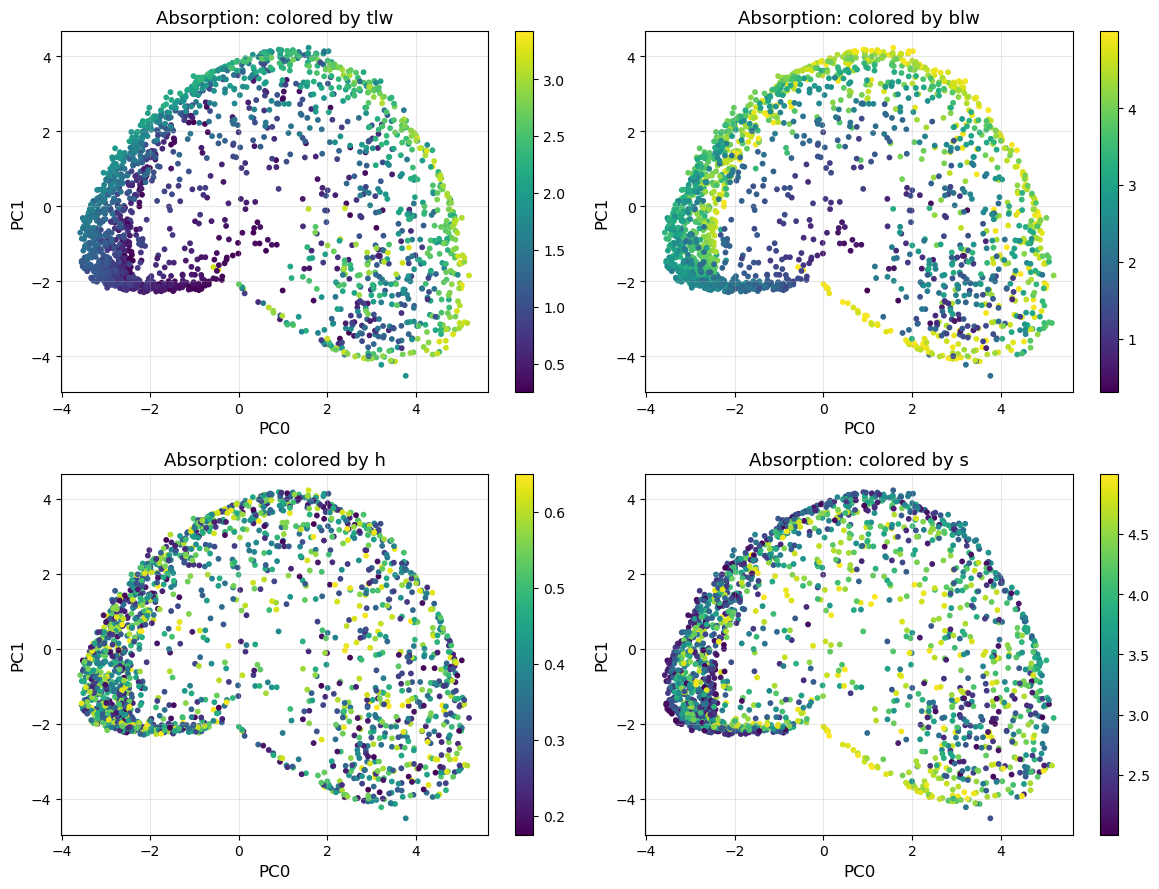

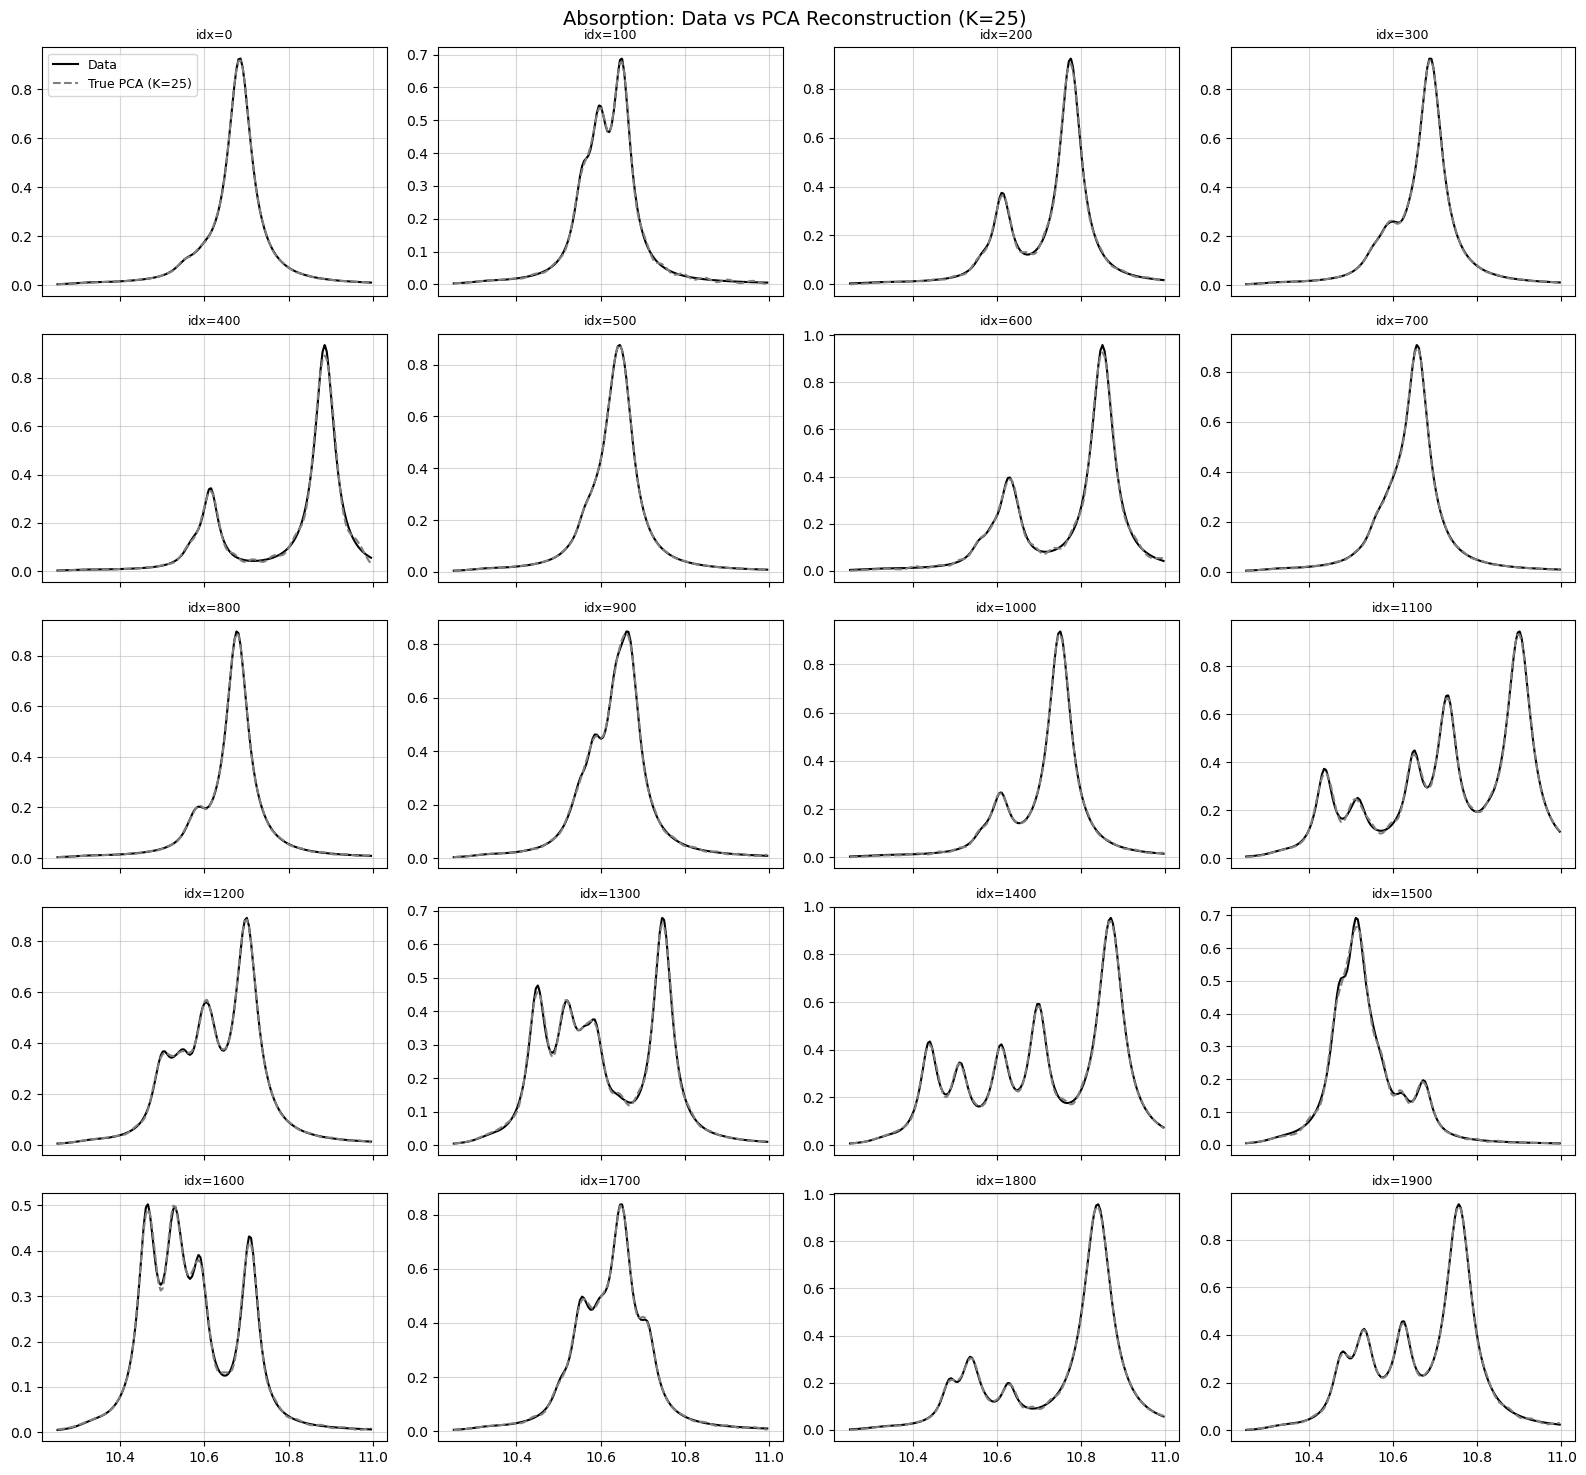

In [2]:
#### DATA PREPROCESSING PIPELINE - PCA FEATURES (4D GEOMETRY) ####
# Config
pd.set_option('display.max_columns', 10)
DATA_PATH = '../data/batch2'
DOMAIN = (10.25, 11.0)
INTERP = 4
TEST_IDX = np.arange(0, 1947, 100)
K = 25
K_SWEEP = [2, 5, 10, 20, 40, 80]
N_PC_SHOW = 6

# BLW/TLW ratio filter. Set MIN_BLW_TLW_RATIO > 0 to drop samples below it.
# Set MAX_BLW_TLW_RATIO to a number to drop samples at or above it; when set,
# a lower floor of 1 is enforced automatically. Either or both may be active.
MIN_BLW_TLW_RATIO = 0
MAX_BLW_TLW_RATIO = None

# Import Data
geom_labels, geom_table, refl_data, abs_data, refl_bg, abs_bg, wl = import_data(DATA_PATH)

# Filter samples by BLW/TLW ratio
if MIN_BLW_TLW_RATIO > 0 or MAX_BLW_TLW_RATIO is not None:
    ratio = geom_table['blw'] / geom_table['tlw']
    keep_mask = pd.Series(True, index=geom_table.index)
    if MIN_BLW_TLW_RATIO > 0:
        keep_mask &= (ratio >= MIN_BLW_TLW_RATIO)
    if MAX_BLW_TLW_RATIO is not None:
        keep_mask &= (ratio >= 1) & (ratio < MAX_BLW_TLW_RATIO)
    n_before = len(geom_table)
    geom_table = geom_table.loc[keep_mask].reset_index(drop=True)
    refl_data  = refl_data.loc[keep_mask].reset_index(drop=True)
    abs_data   = abs_data.loc[keep_mask].reset_index(drop=True)
    print(f'BLW/TLW filter (min={MIN_BLW_TLW_RATIO}, max={MAX_BLW_TLW_RATIO}): kept {len(geom_table)}/{n_before} samples')
    # Re-space TEST_IDX evenly across the filtered sample space (same count as before)
    TEST_IDX = np.linspace(0, len(geom_table) - 1, len(TEST_IDX)).astype(int)

# Print Data and geometry Table for inspection
# print(f'\ngeometry labels (4D):\n{geom_labels}\n')
# print(f'geometry_table (4D):\n{geom_table.head()}\n')
# print(f'absorption data:\n{abs_data.head()}\n')
# print(f'absorption background:\n{abs_bg.head()}\n')

# Build and fit preprocessing pipelines
abs_pipe  = build_pca_pipeline(K, DOMAIN, INTERP, background=abs_bg)
abs_ft_pca  = abs_pipe.fit_transform(abs_data)
abs_pca  = abs_pipe.named_steps['pca'].artifacts_

# Processed spectra (all steps except PCA) — used by exploration plots below
abs_data  = abs_pipe[:-1].fit_transform(abs_data)
wl = abs_data.columns.to_numpy(dtype=float)

# Print feature table for inspection
print(f'Feature table (abs):\n{abs_ft_pca.head()}\n')


#### EXPLORATION PLOTS ####
# 1) Scree / cumulative explained variance
plot_scree(abs_pca, 'Absorption', k_max=35)

# 2) Shapes of the first N principal components
plot_pc_shapes(abs_pca, 'Absorption', N_PC_SHOW)

# 3) Reconstruction fidelity vs K on a single example spectrum
demo_idx = int(TEST_IDX[len(TEST_IDX) // 2])
plot_k_sweep_reconstruction(abs_data, abs_pca, demo_idx, K_SWEEP, 'Absorption')

# 4) Spectral MSE and peak-location MAE vs K (dataset-wide diagnostic)
plot_k_sweep_error(abs_data, abs_pca, K_SWEEP, 'Absorption')

# 5) Latent space scatter: PC0 vs PC1 colored by each geometry parameter (all 4).
plot_latent_colored_by_geom(abs_ft_pca, geom_table, geom_labels, 'Absorption')

# 6) Reconstruction grid: data (target) vs K-component PCA reconstruction
#    for each sample in TEST_IDX. Direct visual check of PCA fidelity.
plot_reconstruction_grid(abs_data, abs_pca, TEST_IDX, 'Absorption')


#### DATA EXPORT ####
pca_ft = {
    "wl": wl,
    "absorption": abs_data,
    "absorption_features": abs_ft_pca,
    "absorption_pca": abs_pca,
    "geometry_labels": geom_labels,
    "geometry_table": geom_table,
    "K": K,
}

data_config = {
    "data_path": DATA_PATH,
    "domain": DOMAIN,
    "interpolation_density": INTERP,
    "K": K,
    "geometry_dim": 4,
    "min_blw_tlw_ratio": MIN_BLW_TLW_RATIO,
    "max_blw_tlw_ratio": MAX_BLW_TLW_RATIO,
}

#### <span style="color:cyan">**Training - Configuration**</span>

In [ ]:
ROOT = "trained_models/pca_4D"
NAME = "pca_4D_n-peak"
DIR = f'{ROOT}/{NAME}'
os.makedirs(f'{DIR}', exist_ok=True)
os.makedirs(f'{DIR}/config', exist_ok=True)
os.makedirs(f'{DIR}/models', exist_ok=True)
os.makedirs(f'{DIR}/results', exist_ok=True)

#### CONFIG ####
# Note that the data and data config comes from the chose preprocessing file
loader_config = {
    "seed": 1234,
    "test_ratio": 0.15,
    "splits": 4,
    "pre_split": {},
    "shuffle": True,
    "batch_size": 16
}
MLP_config = {
    "hidden_dim": 512,
    "n_layers": 3,
    "k": K,
    "p": 0.008894,
    'input_dim': 4,
    "peak_weighted_loss": True,
}
train_config = {
    "epochs": 300,
    "lr": 0.001541,
    "wd": 2.1989e-05,
    "patience": 30,
    "path": f'{DIR}/models'
}

# Peak-weighting config. Weight = (n_peaks ** ALPHA), mean-normalized so the
# overall loss magnitude stays comparable to unweighted training.
PEAK_PROMINENCE = 0.05    # fraction of per-spectrum max
PEAK_WEIGHT_ALPHA = 2.0   # 0 -> uniform, 1 -> linear, 2 -> square

#### SETUP OBJECTS ####
data = PCADataset(
    pca_ft['geometry_table'],
    pca_ft['absorption_features'],
    pca_ft['absorption_pca'],
    normalize_geom = True,
    normalize_feat = False
)

# Raw absorption spectra aligned with dataset order (used for 3-curve plots
# and for peak counting below).
_sorted_ids = pca_ft['geometry_table'].sort_index().index
_raw_abs = pca_ft['absorption'].loc[_sorted_ids].to_numpy()

#### PEAK-COUNT WEIGHTS ####
# Diagnostics on PCA_MLP_4D show error scales steeply with peak count
# (1 -> 0.05 RMSE, 5 -> 0.35 RMSE), so up-weight multi-peak samples to push
# capacity toward them. Weights apply during training only - val/test loss
# is reported unweighted so it remains comparable across runs.
from scipy.signal import find_peaks
peak_counts = np.array([
    len(find_peaks(s, prominence=PEAK_PROMINENCE * s.max())[0])
    for s in _raw_abs
], dtype=np.float32)
peak_counts = np.maximum(peak_counts, 1.0)  # never zero (avoid silenced samples)
sample_weights = peak_counts ** PEAK_WEIGHT_ALPHA
sample_weights = sample_weights / sample_weights.mean()
data.set_sample_weights(sample_weights)
print(f'Peak counts:  min={int(peak_counts.min())}  '
      f'max={int(peak_counts.max())}  '
      f'mean={peak_counts.mean():.2f}')
print('Weight by peak count (mean-normalized):')
for c in np.unique(peak_counts.astype(int)):
    sel = peak_counts.astype(int) == c
    print(f'  n_peaks={c}:  n_samples={int(sel.sum()):4d}   '
          f'weight={sample_weights[sel][0]:.3f}')

kf_indices, test_indices = generate_kfold(
    data,
    loader_config['splits'],
    loader_config['seed'],
    loader_config['test_ratio']
)
train_config['test_indices'] = test_indices

Peak counts:  min=1  max=6  mean=2.53
Weight by peak count (mean-normalized):
  n_peaks=1:  n_samples= 431   weight=0.126
  n_peaks=2:  n_samples= 733   weight=0.504
  n_peaks=3:  n_samples= 280   weight=1.134
  n_peaks=4:  n_samples= 342   weight=2.015
  n_peaks=5:  n_samples= 154   weight=3.149
  n_peaks=6:  n_samples=   7   weight=4.535


#### <span style="color:cyan">**Training - CV**</span>

In [20]:
model = PcaMLP(
    MLP_config['k'],
    MLP_config["hidden_dim"],
    MLP_config["n_layers"],
    MLP_config['p'],
    input_dim = MLP_config["input_dim"],
    peak_weighted_loss = MLP_config["peak_weighted_loss"],
)

#### TRAINING LOOP ####
fold_metrics = {
    "best_val_coeff_mse": [],
    "best_val_recon_mse": [],
    "best_val_recon_rmse": [],
    "peak_mae": [],
    "peak_loc_error_um": [],
    "train_val_gap_coeff": [],
    "best_epoch": [],
    "epochs_trained": [],
}
fold_histories = []

wl_tensor = torch.tensor(np.asarray(data.wl), dtype=torch.float32)

for i, (train_idx, val_idx) in enumerate(kf_indices):
    os.makedirs(f'{train_config["path"]}/fold{i}', exist_ok=True)

    model = PcaMLP(
        MLP_config['k'],
        MLP_config["hidden_dim"],
        MLP_config["n_layers"],
        MLP_config['p'],
        input_dim=MLP_config["input_dim"],
        peak_weighted_loss=MLP_config["peak_weighted_loss"],
    )

    train_loader, val_loader = create_dataloader_kfold(
        data,
        loader_config['seed'],
        train_idx,
        val_idx,
        loader_config['batch_size']
    )

    model_state, history = train_pca_regression(
        model,
        data,
        train_loader,
        val_loader,
        train_config["epochs"],
        train_config['lr'],
        train_config["wd"],
        train_config["patience"],
        f'{train_config["path"]}/fold{i}'
    )
    fold_histories.append(history)

    # Per-fold scalar metrics. train_pca_regression reloads the best checkpoint
    # before returning, so `model` is the best-val-epoch weights.
    best_ep = history["stop_epoch"]
    best_val_coeff = history["val_loss"][best_ep]
    best_val_recon = history["val_loss_recon"][best_ep]
    best_train_coeff = history["train_loss"][best_ep]

    # Peak metrics on the val set with the loaded best model.
    model.eval()
    peak_abs_errs = []
    peak_loc_errs = []
    with torch.no_grad():
        for batch in val_loader:
            geom, feat = batch[0], batch[1]
            pred_spec = data.reconstruct_spectrum(model(geom))
            true_spec = data.reconstruct_spectrum(feat)
            pred_peak = pred_spec.max(dim=-1)
            true_peak = true_spec.max(dim=-1)
            peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
            peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())
    peak_mae = torch.cat(peak_abs_errs).mean().item()
    peak_loc_err = torch.cat(peak_loc_errs).mean().item()

    fold_metrics["best_val_coeff_mse"].append(float(best_val_coeff))
    fold_metrics["best_val_recon_mse"].append(float(best_val_recon))
    fold_metrics["best_val_recon_rmse"].append(float(math.sqrt(best_val_recon)))
    fold_metrics["peak_mae"].append(float(peak_mae))
    fold_metrics["peak_loc_error_um"].append(float(peak_loc_err))
    fold_metrics["train_val_gap_coeff"].append(float(best_val_coeff - best_train_coeff))
    fold_metrics["best_epoch"].append(int(best_ep))
    fold_metrics["epochs_trained"].append(int(len(history["val_loss"])))

Early stopping triggered at epoch 140
Early stopping triggered at epoch 156
Early stopping triggered at epoch 169
Early stopping triggered at epoch 152


#### <span style="color:cyan">**Training - Final Model (all non-test)**</span>

In [21]:
#### FINAL MODEL ####
# Train on all non-test indices for a fixed number of epochs (informed by CV
# best-epoch mean) so the test indices stay clean for a single honest eval.
os.makedirs(f'{train_config["path"]}/final_model', exist_ok=True)

non_test_idx = np.setdiff1d(np.arange(len(data)), test_indices)
# mean + 0.5*std: with ReduceLROnPlateau the late epochs run at a tiny lr
# and only refine - going slightly past fold convergence helps settling.
final_epochs = int(math.ceil(float(np.mean(fold_metrics["best_epoch"]) + 0.5 * np.std(fold_metrics["best_epoch"]))))

final_model_net = PcaMLP(
    MLP_config['k'],
    MLP_config["hidden_dim"],
    MLP_config["n_layers"],
    MLP_config['p'],
    input_dim=MLP_config["input_dim"],
    peak_weighted_loss=MLP_config["peak_weighted_loss"],
)

# Reuse create_dataloader_kfold: val_loader here serves as the test loader,
# used ONLY for post-training evaluation (train_pca_regression_final doesn't
# see it).
final_train_loader, test_loader = create_dataloader_kfold(
    data,
    loader_config['seed'],
    non_test_idx,
    test_indices,
    loader_config['batch_size']
)

_, final_history = train_pca_regression_final(
    final_model_net,
    data,
    final_train_loader,
    final_epochs,
    train_config['lr'],
    train_config['wd'],
    f'{train_config["path"]}/final_model'
)

# Single honest evaluation on test_indices (unweighted MSE, like PCA_MLP_4D).
final_model_net.eval()
test_coeff_sum = 0.0
test_recon_sum = 0.0
test_samples = 0
peak_abs_errs = []
peak_loc_errs = []
_mse = torch.nn.MSELoss()
with torch.no_grad():
    for batch in test_loader:
        geom, feat = batch[0], batch[1]
        pred = final_model_net(geom)
        pred_spec = data.reconstruct_spectrum(pred)
        true_spec = data.reconstruct_spectrum(feat)

        batch_n = geom.shape[0]
        test_coeff_sum += _mse(pred, feat).item() * batch_n
        test_recon_sum += ((pred_spec - true_spec) ** 2).mean().item() * batch_n
        test_samples += batch_n

        pred_peak = pred_spec.max(dim=-1)
        true_peak = true_spec.max(dim=-1)
        peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
        peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())

test_coeff_mse = test_coeff_sum / max(test_samples, 1)
test_recon_mse = test_recon_sum / max(test_samples, 1)
final_peak_mae = torch.cat(peak_abs_errs).mean().item()
final_peak_loc = torch.cat(peak_loc_errs).mean().item()
final_train_coeff = final_history["train_loss"][-1]
final_train_recon = final_history["train_loss_recon"][-1]

final_metrics = {
    "test_coeff_mse": float(test_coeff_mse),
    "test_recon_mse": float(test_recon_mse),
    "test_recon_rmse": float(math.sqrt(test_recon_mse)),
    "peak_mae": float(final_peak_mae),
    "peak_loc_error_um": float(final_peak_loc),
    "train_test_gap_coeff": float(test_coeff_mse - final_train_coeff),
    "train_test_gap_recon": float(test_recon_mse - final_train_recon),
    "epochs_trained": int(final_epochs),
    "n_train": int(len(non_test_idx)),
    "n_test": int(len(test_indices)),
}

Final | Epoch 001/129 | K= 25 | lr=1.54e-03 | Train REG: 0.694536 | Train RECON: 2.134e-02
Final | Epoch 002/129 | K= 25 | lr=1.54e-03 | Train REG: 0.397842 | Train RECON: 1.123e-02
Final | Epoch 003/129 | K= 25 | lr=1.54e-03 | Train REG: 0.337826 | Train RECON: 9.054e-03
Final | Epoch 004/129 | K= 25 | lr=1.54e-03 | Train REG: 0.272998 | Train RECON: 7.148e-03
Final | Epoch 005/129 | K= 25 | lr=1.54e-03 | Train REG: 0.224474 | Train RECON: 6.110e-03
Final | Epoch 006/129 | K= 25 | lr=1.54e-03 | Train REG: 0.225950 | Train RECON: 5.925e-03
Final | Epoch 007/129 | K= 25 | lr=1.54e-03 | Train REG: 0.190403 | Train RECON: 5.084e-03
Final | Epoch 008/129 | K= 25 | lr=1.54e-03 | Train REG: 0.166283 | Train RECON: 4.499e-03
Final | Epoch 009/129 | K= 25 | lr=1.54e-03 | Train REG: 0.155312 | Train RECON: 4.068e-03
Final | Epoch 010/129 | K= 25 | lr=1.54e-03 | Train REG: 0.148910 | Train RECON: 4.035e-03
Final | Epoch 011/129 | K= 25 | lr=1.54e-03 | Train REG: 0.147160 | Train RECON: 3.869e-03

In [22]:
#### AGGREGATE + SAVE ####
summary = {
    k: {"mean": float(np.mean(v)), "std": float(np.std(v))}
    for k, v in fold_metrics.items()
}
kfold_results = {
    "config": {
        "data": data_config,
        "loader": loader_config,
        "model": MLP_config,
        "training": {k: v for k, v in train_config.items() if k != "path"},
    },
    "per_fold": fold_metrics,
    "summary": summary,
    "final_model": final_metrics,
}
def _json_default(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    raise TypeError(f"Not JSON serializable: {type(o).__name__}")

with open(f'{DIR}/config/kfold_metrics.json', "w") as f:
    json.dump(kfold_results, f, indent=4, default=_json_default)


#### PRINT SUMMARY ####
name_w = max(len(k) for k in summary) + 2
print(f"\n{'='*72}")
print(f"K-Fold Summary  ({loader_config['splits']} folds)  —  {NAME}")
print(f"{'='*72}")
print(f"{'metric':<{name_w}} {'mean':>12} {'std':>12} {'per-fold':>30}")
print("-" * 72)
for k, v in summary.items():
    per_fold_str = ", ".join(f"{x:.4g}" for x in fold_metrics[k])
    print(f"{k:<{name_w}} {v['mean']:>12.6g} {v['std']:>12.6g}   [{per_fold_str}]")
print("=" * 72)

fm_w = max(len(k) for k in final_metrics) + 2
print(f"\n{'='*72}")
print(f"Final Model (trained on non-test, evaluated once on test)")
print(f"{'='*72}")
for k, v in final_metrics.items():
    fmt = f"{v:>12.6g}" if isinstance(v, float) else f"{v:>12d}"
    print(f"{k:<{fm_w}} {fmt}")
print("=" * 72)



K-Fold Summary  (4 folds)  —  n_peak_weighted_v1
metric                        mean          std                       per-fold
------------------------------------------------------------------------
best_val_coeff_mse       0.0377203   0.00423211   [0.03382, 0.03461, 0.03789, 0.04456]
best_val_recon_mse      0.00125567  0.000140882   [0.001126, 0.001152, 0.001261, 0.001483]
best_val_recon_rmse      0.0353816   0.00195137   [0.03355, 0.03394, 0.03551, 0.03851]
peak_mae                 0.0401162   0.00166739   [0.04072, 0.03742, 0.04035, 0.04197]
peak_loc_error_um       0.00821956   0.00105095   [0.007222, 0.007428, 0.00834, 0.009888]
train_val_gap_coeff      0.0239136   0.00536149   [0.01817, 0.02084, 0.02423, 0.03242]
best_epoch                  123.25      10.3531   [109, 125, 138, 121]
epochs_trained              124.25      10.3531   [110, 126, 139, 122]

Final Model (trained on non-test, evaluated once on test)
test_coeff_mse            0.0628456
test_recon_mse           0.00209

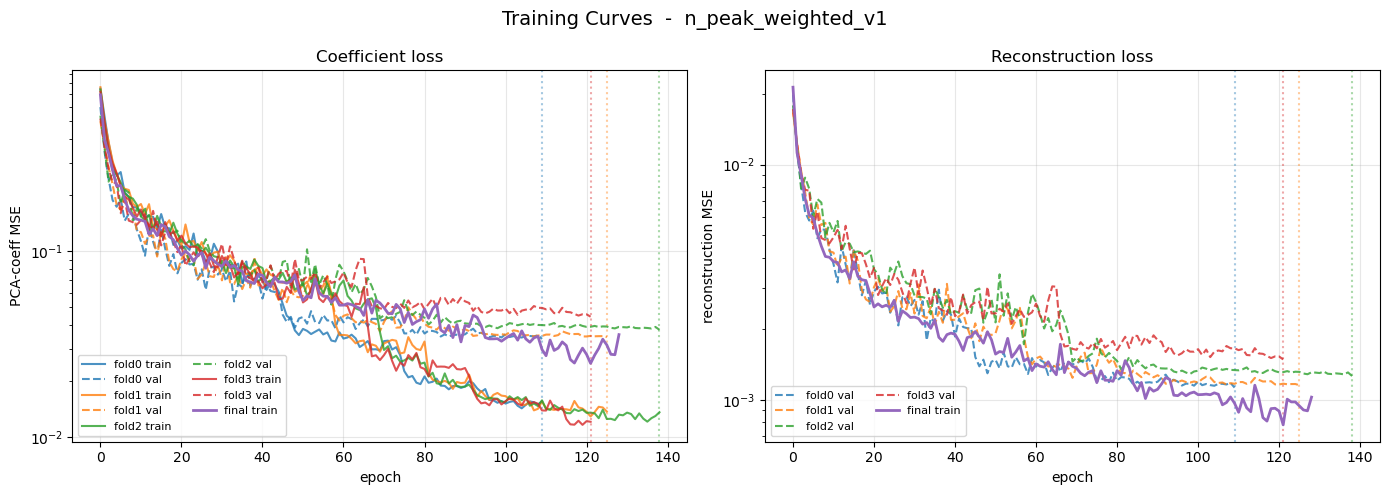

In [23]:
#### PLOT TRAINING CURVES ####
# Train/val loss vs epoch for every CV fold, plus the final-model train curve.
# Folds only log train_loss (coeff); recon is val-only for folds. The final
# model logs train_loss_recon, so train recon is plotted for the final curve.
n_folds_plot = len(fold_histories)
colors = plt.cm.tab10(np.arange(n_folds_plot + 1))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

panels = [
    ("train_loss",        "val_loss",        "PCA-coeff MSE",     "Coefficient loss"),
    (None,                "val_loss_recon",  "reconstruction MSE","Reconstruction loss"),
]
final_train_keys = ["train_loss", "train_loss_recon"]
for ax, (tk, vk, ylabel, title), final_tk in zip(axes, panels, final_train_keys):
    for i, h in enumerate(fold_histories):
        if tk is not None:
            ep = np.arange(len(h[tk]))
            ax.plot(ep, h[tk], color=colors[i], linestyle='-',  alpha=0.8, label=f'fold{i} train')
        ep_v = np.arange(len(h[vk]))
        ax.plot(ep_v, h[vk], color=colors[i], linestyle='--', alpha=0.8, label=f'fold{i} val')
        ax.axvline(h["stop_epoch"], color=colors[i], linestyle=':', alpha=0.4)
    ax.plot(
        np.arange(len(final_history[final_tk])), final_history[final_tk],
        color=colors[-1], linestyle='-', linewidth=2, label='final train'
    )
    ax.set_yscale('log')
    ax.set_xlabel('epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle(f'Training Curves  -  {NAME}', fontsize=14)
fig.tight_layout()
plt.show()

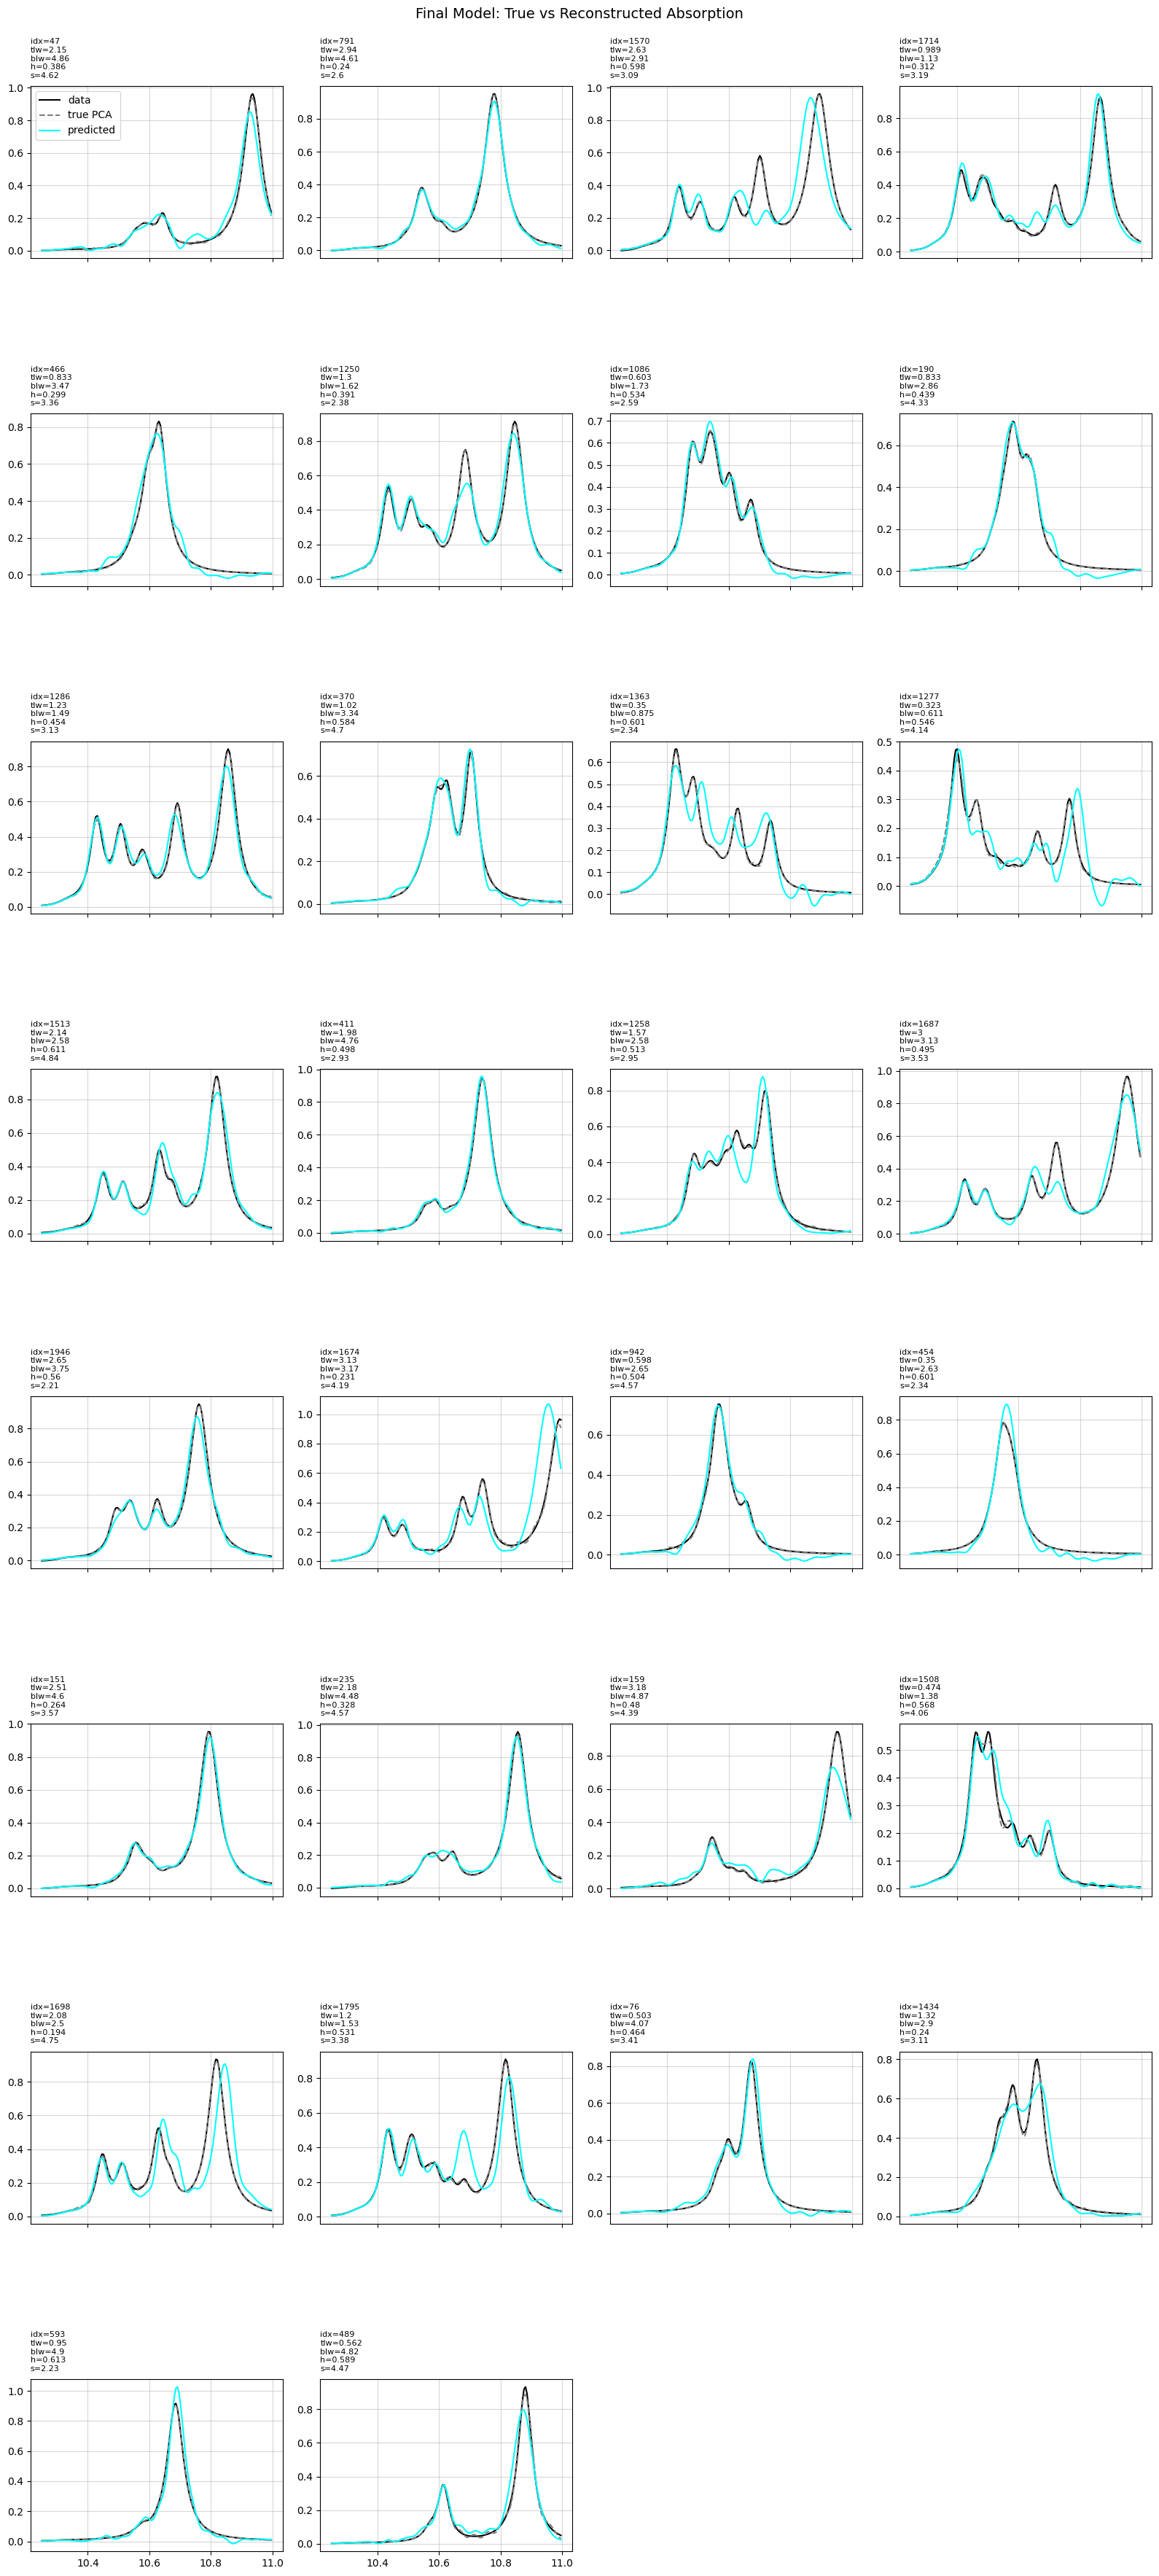

In [24]:
#### PLOT FINAL MODEL RECONSTRUCTIONS ####
plot_idx = np.asarray(test_indices)[::10]

final_model_net.eval()
with torch.no_grad():
    geom_sel = data.geom[plot_idx]
    feat_sel = data.feat[plot_idx]
    pred_sel = final_model_net(geom_sel)
    pred_spec_sel = data.reconstruct_spectrum(pred_sel).numpy()
    true_spec_sel = data.reconstruct_spectrum(feat_sel).numpy()
    raw_spec_sel = _raw_abs[plot_idx]

wl_plot = np.asarray(data.wl)
geom_table_sorted = pca_ft['geometry_table'].sort_index()
n_plot = len(plot_idx)
ncols = 4
nrows = (n_plot + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, idx in enumerate(plot_idx):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_sel[i], color='k', label='data')
    ax.plot(wl_plot, true_spec_sel[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, pred_spec_sel[i], color='cyan', label='predicted')
    geom_row = geom_table_sorted.iloc[int(idx)]
    title = f"idx={int(idx)}\n" + "\n".join(
        f"{name}={geom_row[name]:.3g}" for name in geom_table_sorted.columns
    )
    ax.set_title(title, fontsize=8, loc='left', pad=8)
    ax.grid(alpha=0.5)
    if i == 0:
        ax.legend()
for j in range(n_plot, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle("Final Model: True vs Reconstructed Absorption", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.95, hspace=0.9)
plt.show()


#### <span style="color:cyan">**Training - Final Model (ensemble)**</span>

In [25]:
#### ENSEMBLE (FOLD MODELS) ####
# Load all fold checkpoints and average their coefficient predictions.
# reconstruct_spectrum is linear so averaging coeffs = averaging spectra.

n_folds = loader_config['splits']
fold_models = []
for i in range(n_folds):
    ckpt = torch.load(
        f'{train_config["path"]}/fold{i}/best_pca_reg.pt',
        weights_only=False
    )
    m = PcaMLP(
        MLP_config['k'],
        MLP_config['hidden_dim'],
        MLP_config['n_layers'],
        MLP_config['p'],
        input_dim=MLP_config['input_dim'],
        peak_weighted_loss=MLP_config['peak_weighted_loss'],
    )
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    fold_models.append(m)

# Evaluate ensemble on test set (unweighted)
ens_coeff_sum = 0.0
ens_recon_sum = 0.0
ens_samples = 0
ens_peak_abs_errs = []
ens_peak_loc_errs = []
_mse = torch.nn.MSELoss()

with torch.no_grad():
    for batch in test_loader:
        geom, feat = batch[0], batch[1]
        ensemble_coeffs = torch.stack([m(geom) for m in fold_models]).mean(dim=0)
        pred_spec = data.reconstruct_spectrum(ensemble_coeffs)
        true_spec = data.reconstruct_spectrum(feat)

        batch_n = geom.shape[0]
        ens_coeff_sum += _mse(ensemble_coeffs, feat).item() * batch_n
        ens_recon_sum += ((pred_spec - true_spec) ** 2).mean().item() * batch_n
        ens_samples += batch_n

        pred_peak = pred_spec.max(dim=-1)
        true_peak = true_spec.max(dim=-1)
        ens_peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
        ens_peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())

ens_coeff_mse = ens_coeff_sum / max(ens_samples, 1)
ens_recon_mse = ens_recon_sum / max(ens_samples, 1)
ens_peak_mae  = torch.cat(ens_peak_abs_errs).mean().item()
ens_peak_loc  = torch.cat(ens_peak_loc_errs).mean().item()

ensemble_metrics = {
    "test_coeff_mse":      float(ens_coeff_mse),
    "test_recon_mse":      float(ens_recon_mse),
    "test_recon_rmse":     float(math.sqrt(ens_recon_mse)),
    "peak_mae":            float(ens_peak_mae),
    "peak_loc_error_um":   float(ens_peak_loc),
    "n_models":            n_folds,
    "n_test":              int(ens_samples),
}

em_w = max(len(k) for k in ensemble_metrics) + 2
print(f"\n{'='*72}")
print(f"Ensemble ({n_folds} fold models, evaluated once on test)")
print(f"{'='*72}")
for k, v in ensemble_metrics.items():
    fmt = f"{v:>12.6g}" if isinstance(v, float) else f"{v:>12d}"
    print(f"{k:<{em_w}} {fmt}")
print("=" * 72)

# Save ensemble metrics alongside the rest
kfold_results['ensemble'] = ensemble_metrics
with open(f'{DIR}/config/kfold_metrics.json', "w") as f:
    json.dump(kfold_results, f, indent=4, default=_json_default)


Ensemble (4 fold models, evaluated once on test)
test_coeff_mse         0.0364593
test_recon_mse        0.00121369
test_recon_rmse        0.0348381
peak_mae               0.0420626
peak_loc_error_um      0.0078378
n_models                       4
n_test                       292


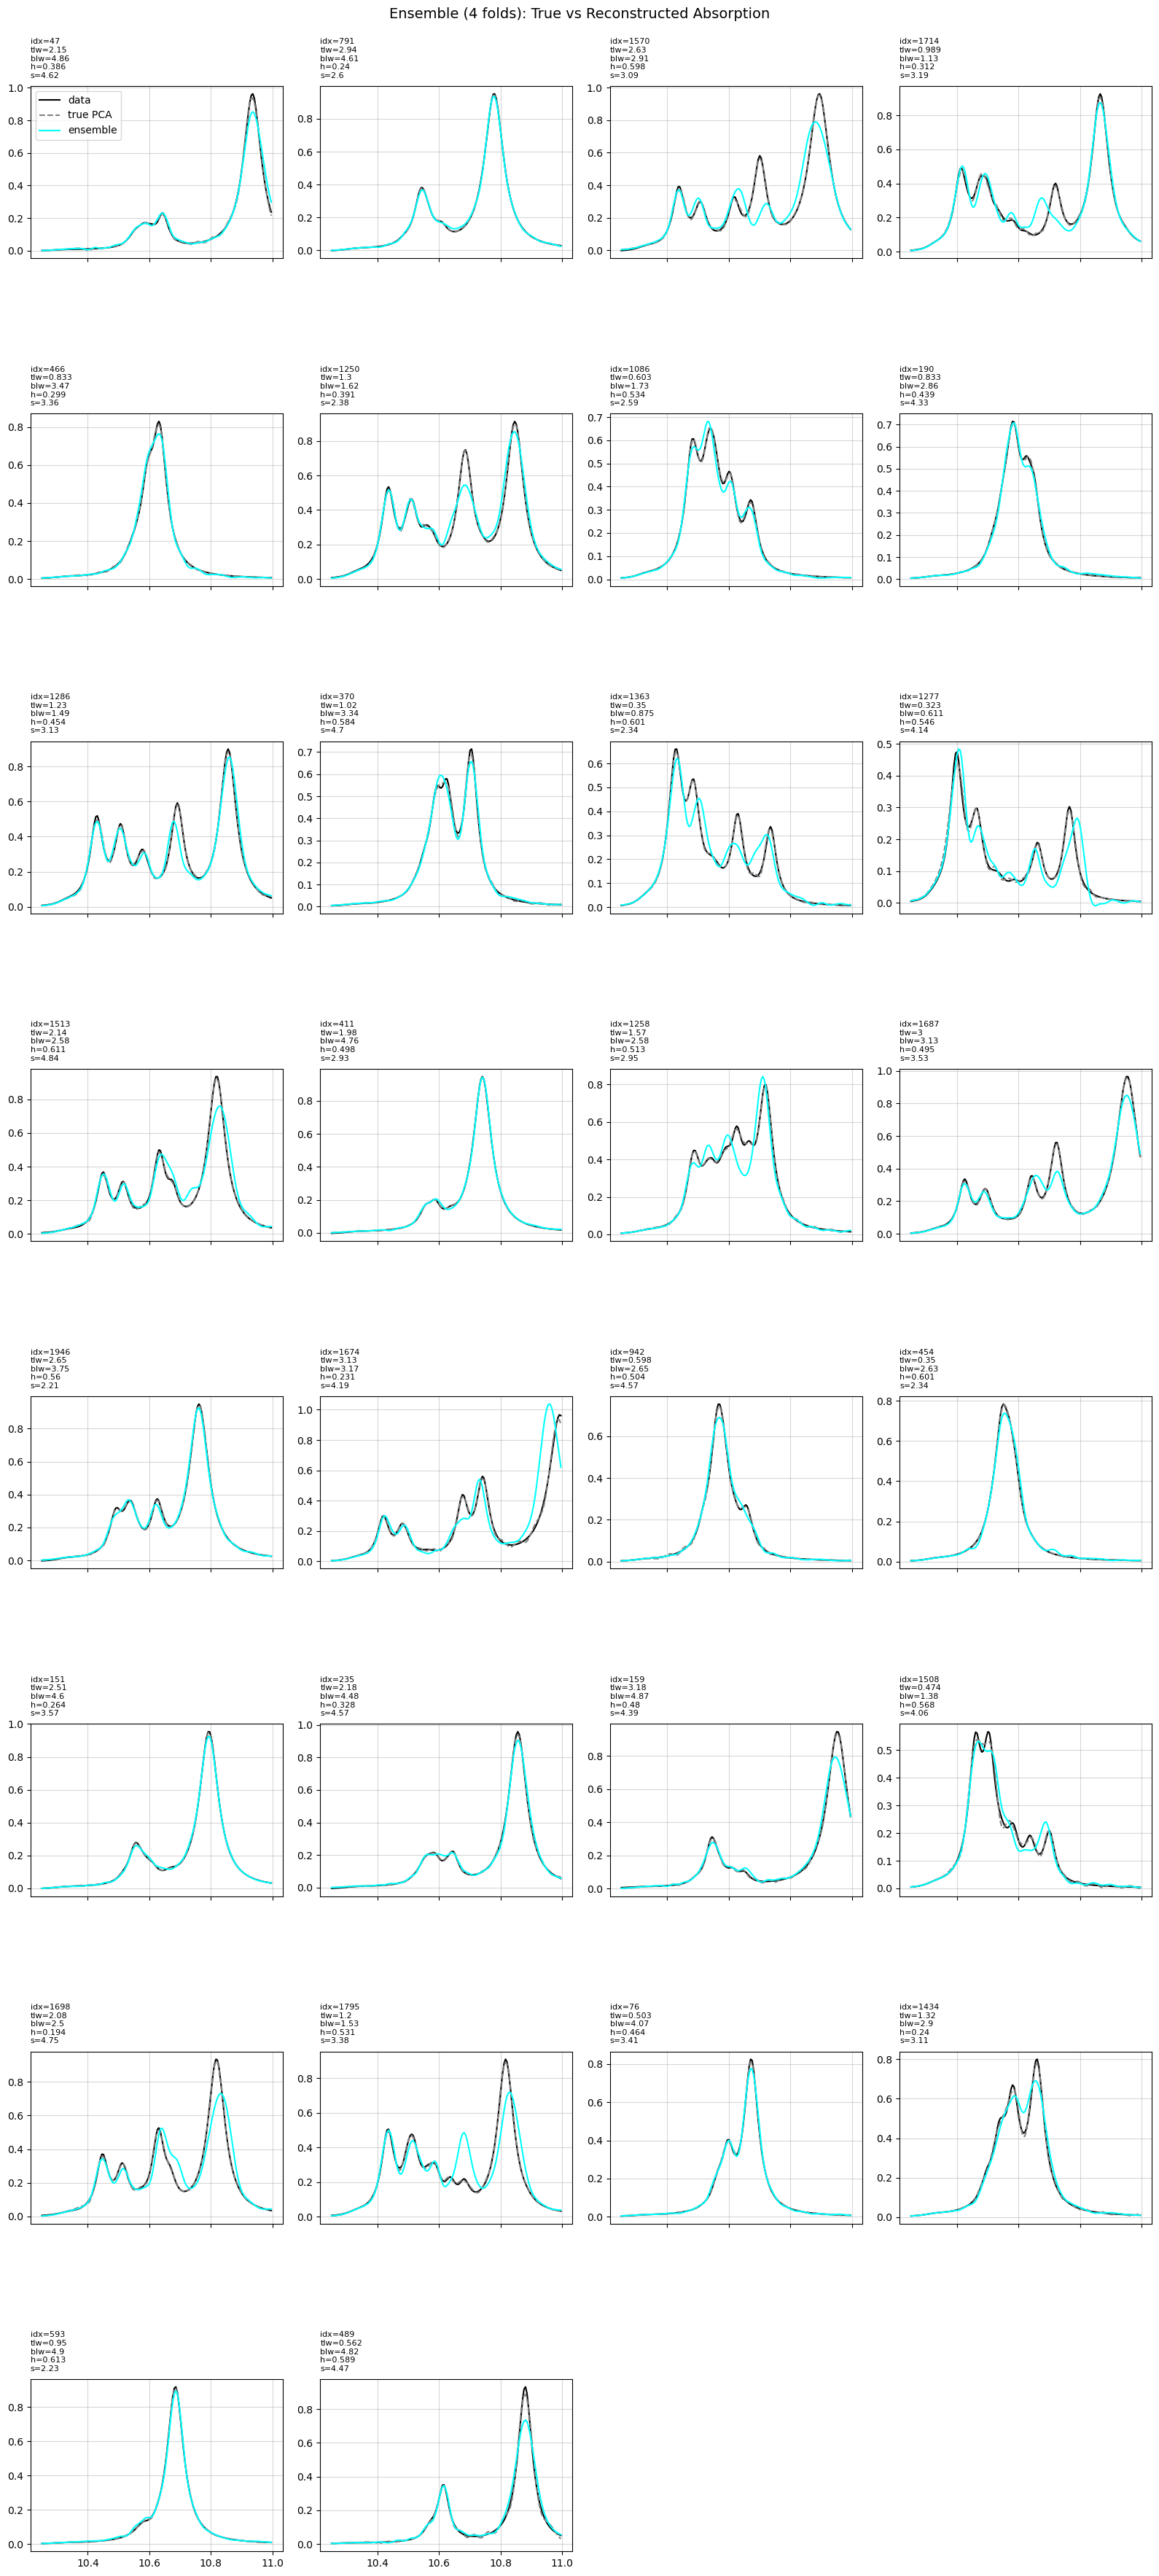

In [26]:
#### PLOT ENSEMBLE RECONSTRUCTIONS ####
with torch.no_grad():
    geom_sel = data.geom[plot_idx]
    feat_sel = data.feat[plot_idx]
    ens_coeffs_sel = torch.stack([m(geom_sel) for m in fold_models]).mean(dim=0)
    ens_spec_sel = data.reconstruct_spectrum(ens_coeffs_sel).numpy()

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, idx in enumerate(plot_idx):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_sel[i], color='k', label='data')
    ax.plot(wl_plot, true_spec_sel[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, ens_spec_sel[i], color='cyan', label='ensemble')
    geom_row = geom_table_sorted.iloc[int(idx)]
    title = f"idx={int(idx)}\n" + "\n".join(
        f"{name}={geom_row[name]:.3g}" for name in geom_table_sorted.columns
    )
    ax.set_title(title, fontsize=8, loc='left', pad=8)
    ax.grid(alpha=0.5)
    if i == 0:
        ax.legend()
for j in range(n_plot, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle(f"Ensemble ({n_folds} folds): True vs Reconstructed Absorption", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.95, hspace=0.9)
plt.show()


#### <span style="color:cyan">**Diagnostics - Error vs Geometry**</span>

In [27]:
#### PER-SAMPLE TEST DIAGNOSTICS ####
# Per-sample coefficient RMSE (across K) using the ensemble. Pair with
# geometry to look for regimes where the model underperforms.
from scipy.stats import pearsonr, spearmanr

test_idx_arr = np.asarray(test_indices)

with torch.no_grad():
    geom_t = data.geom[test_idx_arr]
    feat_t = data.feat[test_idx_arr]
    ens_pred_t = torch.stack([m(geom_t) for m in fold_models]).mean(dim=0)
    coeff_rmse_per_sample = ((ens_pred_t - feat_t) ** 2).mean(dim=1).sqrt().numpy()
    pred_spec_t = data.reconstruct_spectrum(ens_pred_t)
    true_spec_t = data.reconstruct_spectrum(feat_t)
    recon_rmse_per_sample = ((pred_spec_t - true_spec_t) ** 2).mean(dim=1).sqrt().numpy()

# geom_table_sorted is iloc-aligned with `data`
geom_test = geom_table_sorted.iloc[test_idx_arr].reset_index(drop=True)
diag_test = pd.DataFrame({
    'coeff_rmse': coeff_rmse_per_sample,
    'recon_rmse': recon_rmse_per_sample,
    'size':       (geom_test['tlw'] + geom_test['blw']).values / 2.0,
    'ratio':      (geom_test['blw'] / geom_test['tlw']).values,
    'tlw':        geom_test['tlw'].values,
    'blw':        geom_test['blw'].values,
})
print(diag_test.describe().round(4))

       coeff_rmse  recon_rmse      size     ratio       tlw       blw
count    292.0000    292.0000  292.0000  292.0000  292.0000  292.0000
mean       0.1387      0.0253    2.3123    2.9493    1.4318    3.1928
std        0.1315      0.0240    0.7894    2.2011    0.7695    1.1366
min        0.0205      0.0037    0.3760    1.0134    0.2730    0.4790
25%        0.0566      0.0103    1.7394    1.5249    0.8020    2.4110
50%        0.0884      0.0161    2.3728    2.2382    1.2652    3.2525
75%        0.1763      0.0322    2.9230    3.5423    1.9923    4.1560
max        0.7573      0.1382    4.0291   13.9525    3.2050    4.9927


(TLW+BLW)/2   Pearson r=-0.279 (p=1.23e-06)   Spearman rho=-0.341 (p=2.08e-09)
BLW/TLW       Pearson r=-0.380 (p=1.77e-11)   Spearman rho=-0.594 (p=3.32e-29)


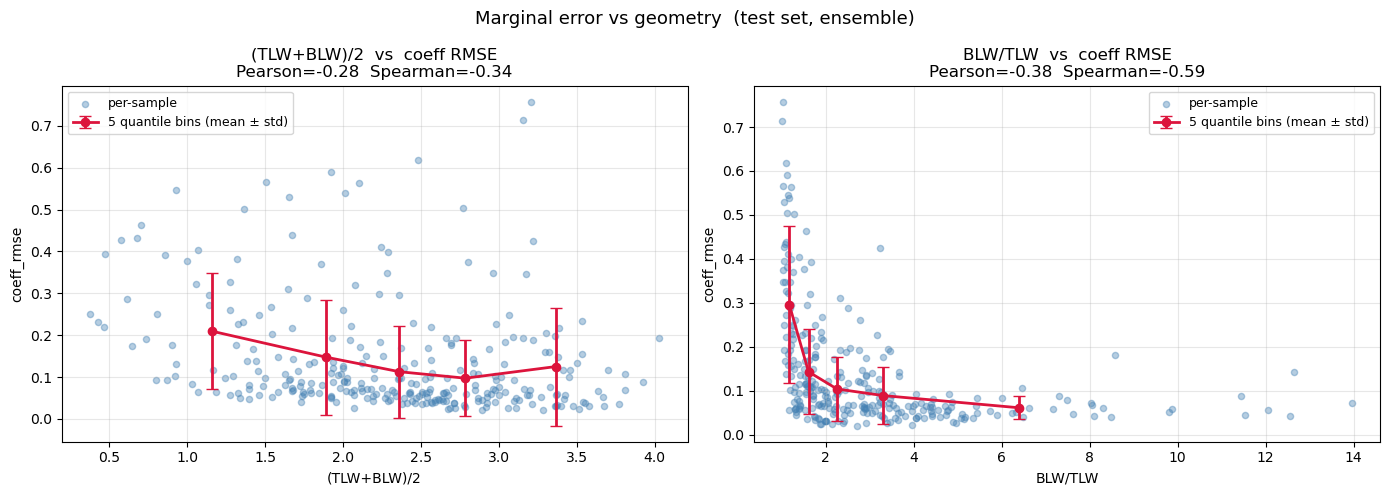

In [28]:
#### MARGINAL: CORRELATION + BINNED RMSE ####
metrics = [('size', '(TLW+BLW)/2'), ('ratio', 'BLW/TLW')]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, label) in zip(axes, metrics):
    x = diag_test[col].values
    y = diag_test['coeff_rmse'].values
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    print(f"{label:12s}  Pearson r={pr:+.3f} (p={pp:.2e})   "
          f"Spearman rho={sr:+.3f} (p={sp:.2e})")

    ax.scatter(x, y, alpha=0.4, s=20, color='steelblue', label='per-sample')

    n_bins = 5
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    bin_id = np.digitize(x, edges[1:-1])
    centers, means, stds = [], [], []
    for b in range(n_bins):
        sel = bin_id == b
        if sel.any():
            centers.append(x[sel].mean())
            means.append(y[sel].mean())
            stds.append(y[sel].std())
    centers, means, stds = map(np.asarray, (centers, means, stds))
    ax.errorbar(centers, means, yerr=stds, color='crimson', marker='o',
                linewidth=2, capsize=4, label=f'{n_bins} quantile bins (mean ± std)')

    ax.set_xlabel(label)
    ax.set_ylabel('coeff_rmse')
    ax.set_title(f'{label}  vs  coeff RMSE\nPearson={pr:+.2f}  Spearman={sr:+.2f}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle('Marginal error vs geometry  (test set, ensemble)', fontsize=13)
fig.tight_layout()
plt.show()

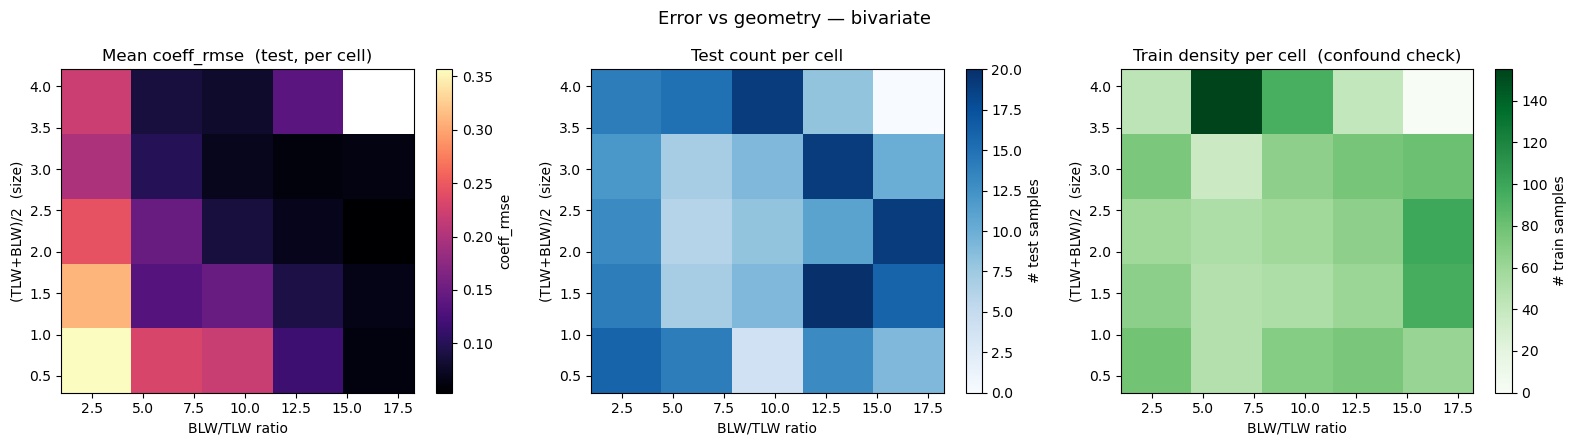


Cells with high error (>= 0.2037) AND low train density (<= 51 samples): 2 / 25
If most high-error cells are also data-sparse, the 'weakness' may be training coverage, not geometry hardness.


In [29]:
#### 2D: MEAN ERROR HEATMAP + TRAIN-DENSITY CONFOUND CHECK ####
# Bin (size, ratio) and view mean coeff_rmse per cell. Compare against
# training-sample density in the same bins to separate "geometry hardness"
# from "data sparsity".
geom_train = geom_table_sorted.iloc[non_test_idx].reset_index(drop=True)
size_train  = ((geom_train['tlw'] + geom_train['blw']) / 2.0).values
ratio_train = (geom_train['blw'] / geom_train['tlw']).values

n_bins = 5
size_edges  = np.quantile(np.concatenate([diag_test['size'].values,  size_train]),
                          np.linspace(0, 1, n_bins + 1))
ratio_edges = np.quantile(np.concatenate([diag_test['ratio'].values, ratio_train]),
                          np.linspace(0, 1, n_bins + 1))
size_edges[-1]  += 1e-9
ratio_edges[-1] += 1e-9

err_sum, _, _   = np.histogram2d(diag_test['size'].values, diag_test['ratio'].values,
                                 bins=[size_edges, ratio_edges],
                                 weights=diag_test['coeff_rmse'].values)
test_count, _, _ = np.histogram2d(diag_test['size'].values, diag_test['ratio'].values,
                                  bins=[size_edges, ratio_edges])
mean_err = np.where(test_count > 0, err_sum / np.maximum(test_count, 1), np.nan)

train_density, _, _ = np.histogram2d(size_train, ratio_train,
                                     bins=[size_edges, ratio_edges])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
extent = [ratio_edges[0], ratio_edges[-1], size_edges[0], size_edges[-1]]

im0 = axes[0].imshow(mean_err, origin='lower', aspect='auto', extent=extent, cmap='magma')
axes[0].set_title('Mean coeff_rmse  (test, per cell)')
fig.colorbar(im0, ax=axes[0], label='coeff_rmse')

im1 = axes[1].imshow(test_count, origin='lower', aspect='auto', extent=extent, cmap='Blues')
axes[1].set_title('Test count per cell')
fig.colorbar(im1, ax=axes[1], label='# test samples')

im2 = axes[2].imshow(train_density, origin='lower', aspect='auto', extent=extent, cmap='Greens')
axes[2].set_title('Train density per cell  (confound check)')
fig.colorbar(im2, ax=axes[2], label='# train samples')

for ax in axes:
    ax.set_xlabel('BLW/TLW ratio')
    ax.set_ylabel('(TLW+BLW)/2  (size)')

fig.suptitle('Error vs geometry — bivariate', fontsize=13)
fig.tight_layout()
plt.show()

# Quick text summary: cells where mean_err is in top quartile AND train density
# is in bottom quartile (suspect "sparse training" rather than "hard geometry").
flat_err     = mean_err[~np.isnan(mean_err)]
err_thresh   = np.quantile(flat_err, 0.75) if flat_err.size else np.nan
train_thresh = np.quantile(train_density, 0.25)
high_err_low_data = (mean_err >= err_thresh) & (train_density <= train_thresh)
print(f"\nCells with high error (>= {err_thresh:.4f}) AND low train density "
      f"(<= {train_thresh:.0f} samples): "
      f"{int(np.nansum(high_err_low_data))} / {mean_err.size}")
print("If most high-error cells are also data-sparse, the 'weakness' may be "
      "training coverage, not geometry hardness.")

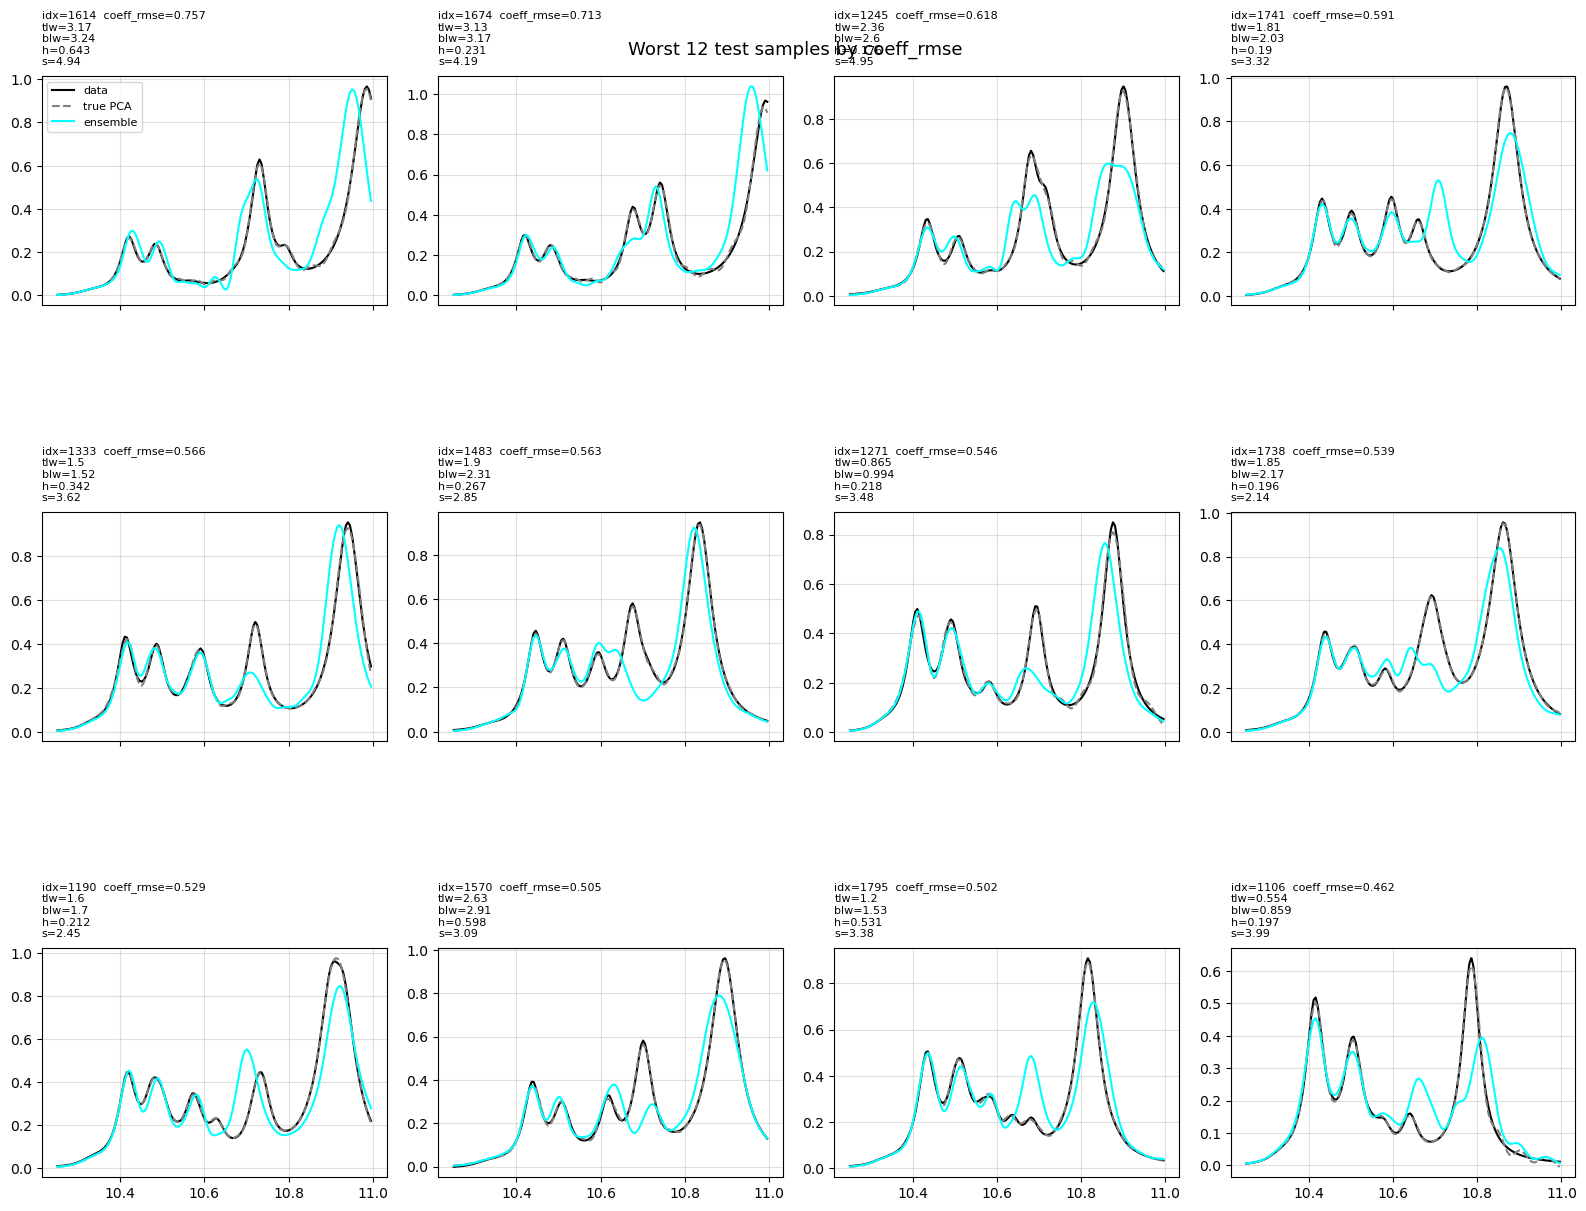

In [30]:
#### WORST-N SPECTRA GRID ####
# Pull the top-N test samples by coeff_rmse and plot pred vs true spectrum.
# Tells you whether failures are amplitude, peak-location, or shape errors.
N_WORST = 12
worst_local = np.argsort(diag_test['coeff_rmse'].values)[::-1][:N_WORST]
worst_global = test_idx_arr[worst_local]

with torch.no_grad():
    geom_w = data.geom[worst_global]
    feat_w = data.feat[worst_global]
    ens_coeffs_w = torch.stack([m(geom_w) for m in fold_models]).mean(dim=0)
    pred_spec_w = data.reconstruct_spectrum(ens_coeffs_w).numpy()
    true_spec_w = data.reconstruct_spectrum(feat_w).numpy()
raw_spec_w = _raw_abs[worst_global]

ncols_w = 4
nrows_w = (N_WORST + ncols_w - 1) // ncols_w
fig, axes = plt.subplots(nrows_w, ncols_w, figsize=(4 * ncols_w, 4 * nrows_w), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, (li, gi) in enumerate(zip(worst_local, worst_global)):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_w[i],  color='k',    label='data')
    ax.plot(wl_plot, true_spec_w[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, pred_spec_w[i], color='cyan', label='ensemble')
    geom_row = geom_table_sorted.iloc[int(gi)]
    rmse = diag_test['coeff_rmse'].iloc[int(li)]
    title = (f"idx={int(gi)}  coeff_rmse={rmse:.3f}\n"
             + "\n".join(f"{c}={geom_row[c]:.3g}" for c in geom_table_sorted.columns))
    ax.set_title(title, fontsize=8, loc='left', pad=8)
    ax.grid(alpha=0.4)
    if i == 0:
        ax.legend(fontsize=8)
for j in range(N_WORST, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle(f'Worst {N_WORST} test samples by coeff_rmse', fontsize=13)
fig.tight_layout()
fig.subplots_adjust(top=0.95, hspace=0.9)
plt.show()

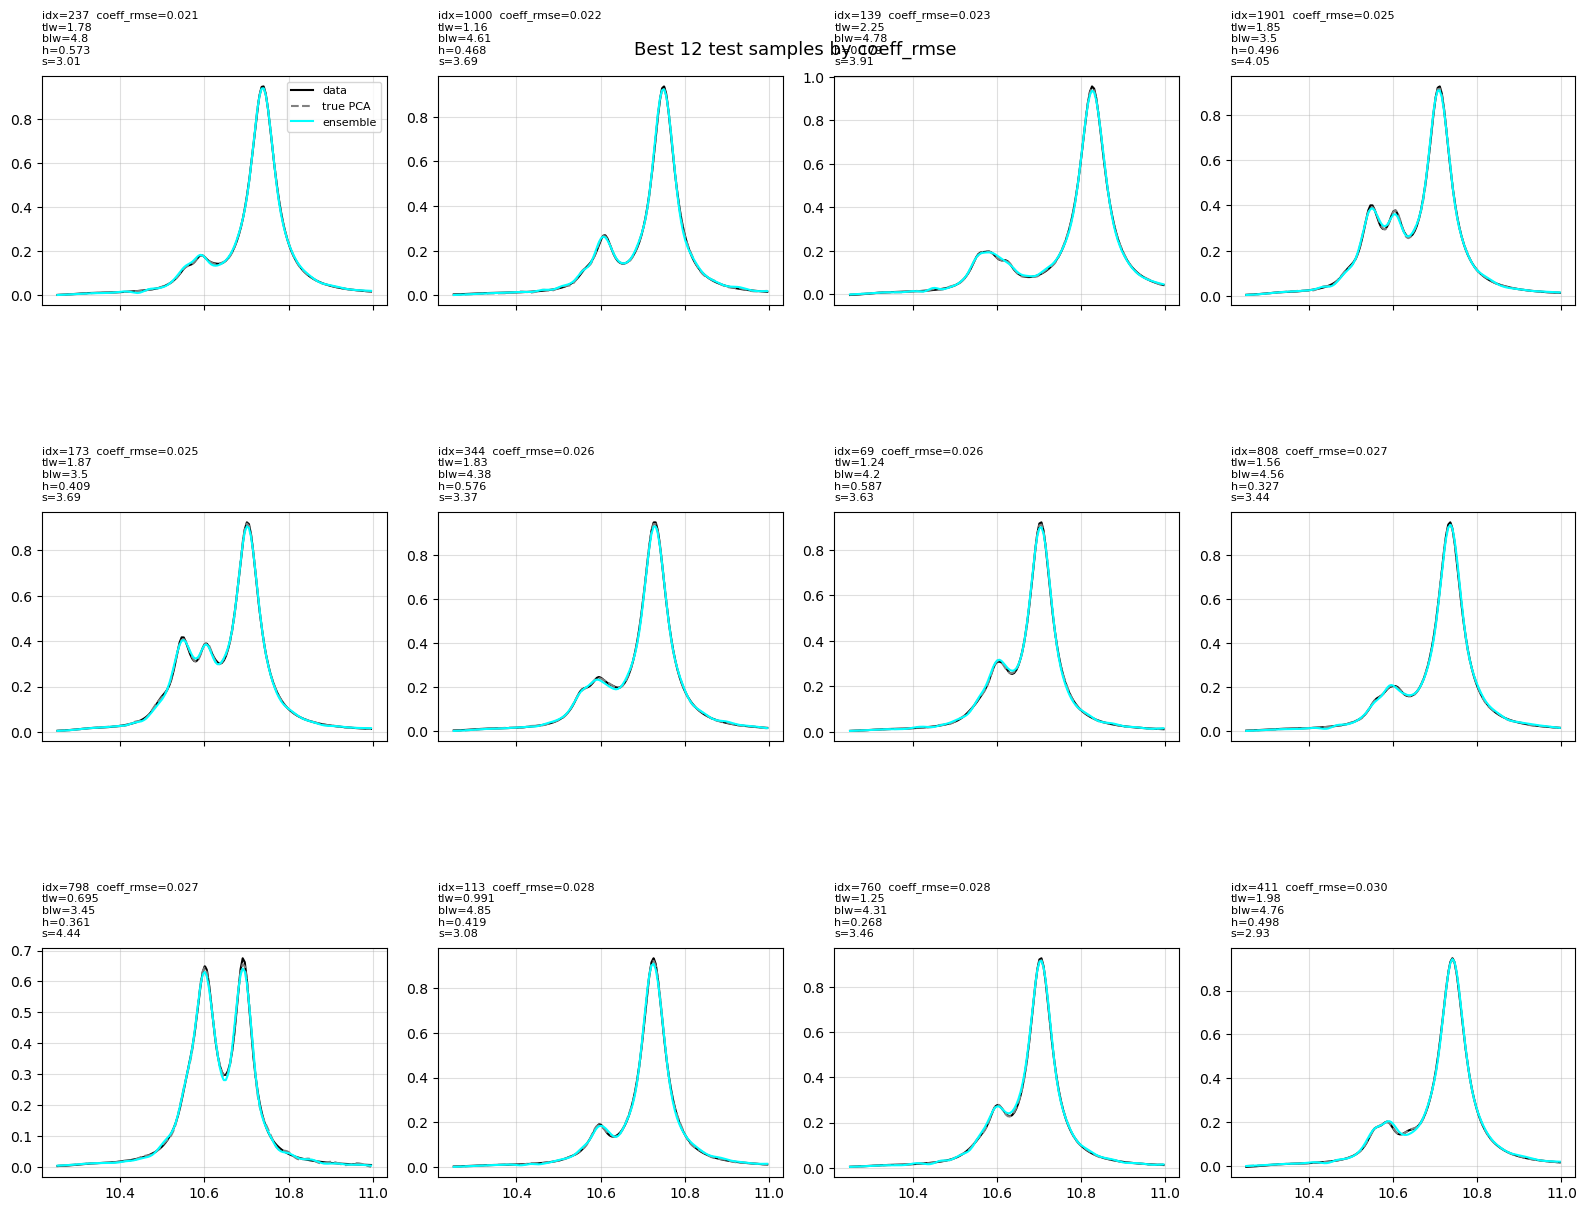

In [31]:
#### BEST-N SPECTRA GRID ####
# Companion to the worst-N grid: top-N test samples with the LOWEST coeff_rmse.
# Useful as a sanity baseline for what "good" looks like under this model.
N_BEST = 12
best_local = np.argsort(diag_test['coeff_rmse'].values)[:N_BEST]
best_global = test_idx_arr[best_local]

with torch.no_grad():
    geom_b = data.geom[best_global]
    feat_b = data.feat[best_global]
    ens_coeffs_b = torch.stack([m(geom_b) for m in fold_models]).mean(dim=0)
    pred_spec_b = data.reconstruct_spectrum(ens_coeffs_b).numpy()
    true_spec_b = data.reconstruct_spectrum(feat_b).numpy()
raw_spec_b = _raw_abs[best_global]

ncols_b = 4
nrows_b = (N_BEST + ncols_b - 1) // ncols_b
fig, axes = plt.subplots(nrows_b, ncols_b, figsize=(4 * ncols_b, 4 * nrows_b), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, (li, gi) in enumerate(zip(best_local, best_global)):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_b[i],  color='k',    label='data')
    ax.plot(wl_plot, true_spec_b[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, pred_spec_b[i], color='cyan', label='ensemble')
    geom_row = geom_table_sorted.iloc[int(gi)]
    rmse = diag_test['coeff_rmse'].iloc[int(li)]
    title = (f"idx={int(gi)}  coeff_rmse={rmse:.3f}\n"
             + "\n".join(f"{c}={geom_row[c]:.3g}" for c in geom_table_sorted.columns))
    ax.set_title(title, fontsize=8, loc='left', pad=8)
    ax.grid(alpha=0.4)
    if i == 0:
        ax.legend(fontsize=8)
for j in range(N_BEST, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle(f'Best {N_BEST} test samples by coeff_rmse', fontsize=13)
fig.tight_layout()
fig.subplots_adjust(top=0.95, hspace=0.9)
plt.show()

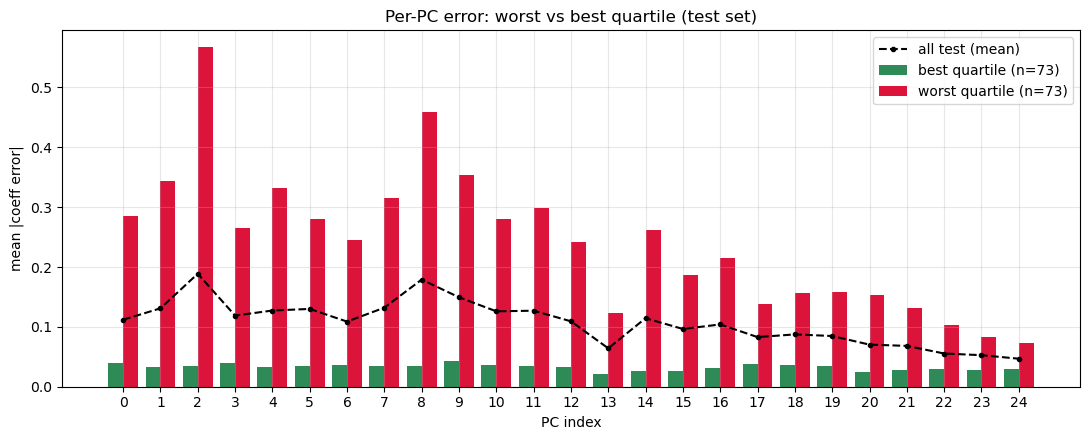


Worst/best |error| ratio by PC (top 5 most-amplified):
  PC02:  best=0.0352   worst=0.5670   ratio=16.10x
  PC08:  best=0.0353   worst=0.4598   ratio=13.04x
  PC01:  best=0.0330   worst=0.3436   ratio=10.40x
  PC04:  best=0.0335   worst=0.3318   ratio=9.91x
  PC14:  best=0.0266   worst=0.2624   ratio=9.87x


In [32]:
#### PER-PC ERROR BREAKDOWN ####
# Mean |error| at each PC index for the worst-quartile vs best-quartile of
# test samples. If failures concentrate on PC0..PC2 the model misses gross
# shape; if on later PCs it misses fine detail.
coeff_resid = (ens_pred_t - feat_t).abs().numpy()  # (N_test, K)
rmse_arr = diag_test['coeff_rmse'].values

q25, q75 = np.quantile(rmse_arr, [0.25, 0.75])
best_mask  = rmse_arr <= q25
worst_mask = rmse_arr >= q75

mean_best  = coeff_resid[best_mask].mean(axis=0)
mean_worst = coeff_resid[worst_mask].mean(axis=0)
mean_all   = coeff_resid.mean(axis=0)

K_pc = coeff_resid.shape[1]
pcs = np.arange(K_pc)

fig, ax = plt.subplots(figsize=(11, 4.5))
w = 0.4
ax.bar(pcs - w/2, mean_best,  width=w, color='seagreen', label=f'best quartile (n={best_mask.sum()})')
ax.bar(pcs + w/2, mean_worst, width=w, color='crimson',  label=f'worst quartile (n={worst_mask.sum()})')
ax.plot(pcs, mean_all, color='k', linestyle='--', marker='.', label='all test (mean)')
ax.set_xlabel('PC index')
ax.set_ylabel('mean |coeff error|')
ax.set_title('Per-PC error: worst vs best quartile (test set)')
ax.set_xticks(pcs)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# Worst-quartile / best-quartile ratio per PC — where amplification is largest
ratio_per_pc = mean_worst / np.maximum(mean_best, 1e-12)
print("\nWorst/best |error| ratio by PC (top 5 most-amplified):")
order = np.argsort(ratio_per_pc)[::-1][:5]
for pc in order:
    print(f"  PC{pc:02d}:  best={mean_best[pc]:.4f}   worst={mean_worst[pc]:.4f}   "
          f"ratio={ratio_per_pc[pc]:.2f}x")

Per-geometry-param correlations (test set, ensemble):
  tlw       Pearson r=+0.156 (p=7.49e-03)   Spearman rho=+0.117 (p=4.49e-02)
  blw       Pearson r=-0.494 (p=2.34e-19)   Spearman rho=-0.567 (p=2.87e-26)
  h         Pearson r=-0.100 (p=8.82e-02)   Spearman rho=-0.046 (p=4.30e-01)
  s         Pearson r=-0.002 (p=9.76e-01)   Spearman rho=+0.053 (p=3.67e-01)


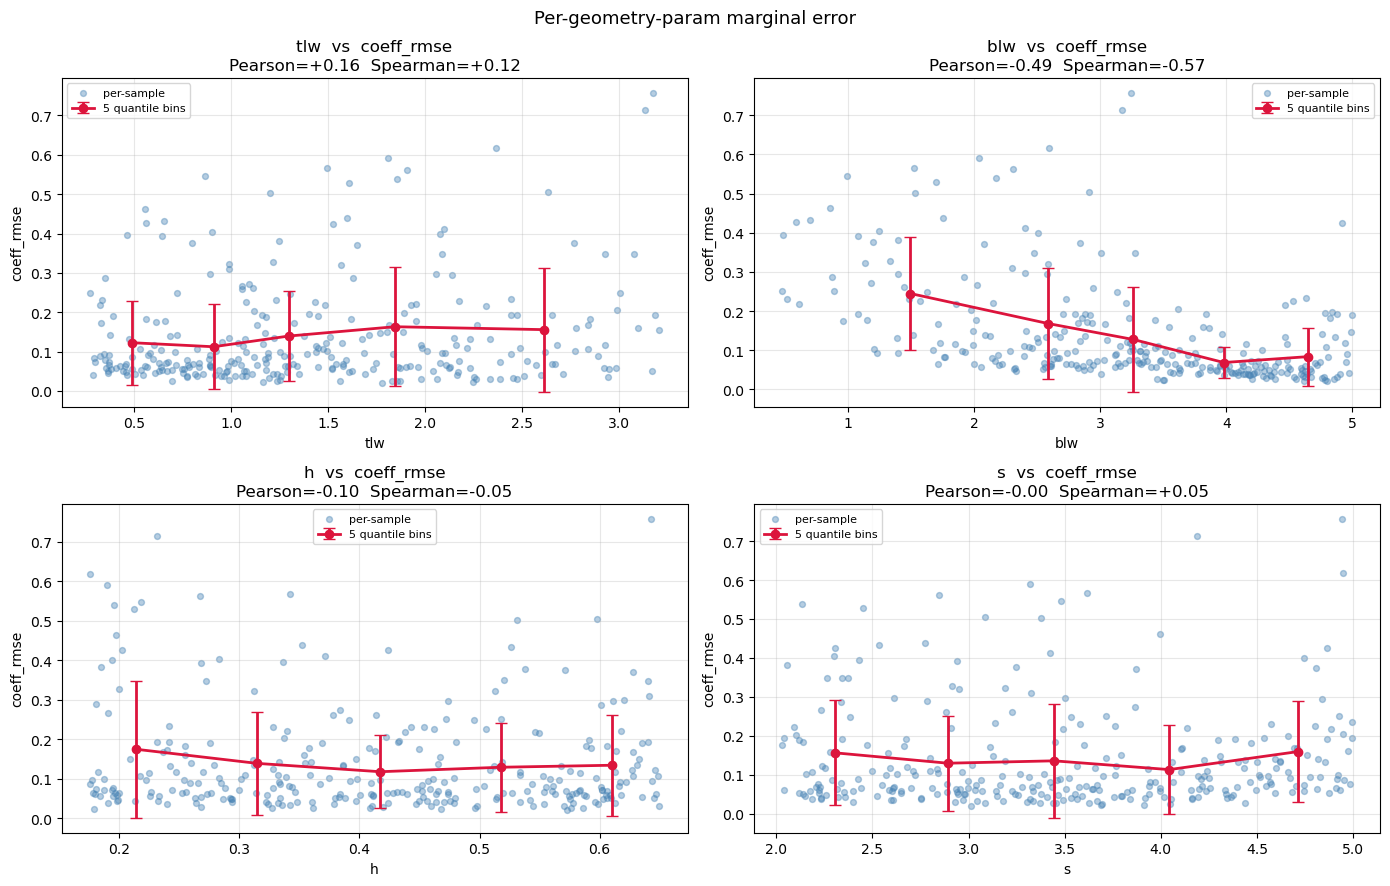

In [33]:
#### RESIDUAL VS EACH GEOMETRY PARAMETER ####
# One panel per geometry column. Same Spearman/Pearson + quantile-bin overlay
# pattern as the marginal cell above, generalized across all 4 inputs.
geom_cols = list(geom_table_sorted.columns)
ncols_g = 2
nrows_g = (len(geom_cols) + ncols_g - 1) // ncols_g
fig, axes = plt.subplots(nrows_g, ncols_g, figsize=(7 * ncols_g, 4.5 * nrows_g))
axes_flat = np.atleast_1d(axes).flatten()

print("Per-geometry-param correlations (test set, ensemble):")
for ax, col in zip(axes_flat, geom_cols):
    x = geom_test[col].values
    y = diag_test['coeff_rmse'].values
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    print(f"  {col:<8}  Pearson r={pr:+.3f} (p={pp:.2e})   "
          f"Spearman rho={sr:+.3f} (p={sp:.2e})")

    ax.scatter(x, y, alpha=0.4, s=18, color='steelblue', label='per-sample')

    n_bins = 5
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    bin_id = np.digitize(x, edges[1:-1])
    centers, means, stds = [], [], []
    for b in range(n_bins):
        sel = bin_id == b
        if sel.any():
            centers.append(x[sel].mean())
            means.append(y[sel].mean())
            stds.append(y[sel].std())
    centers, means, stds = map(np.asarray, (centers, means, stds))
    ax.errorbar(centers, means, yerr=stds, color='crimson', marker='o',
                linewidth=2, capsize=4, label=f'{n_bins} quantile bins')

    ax.set_xlabel(col)
    ax.set_ylabel('coeff_rmse')
    ax.set_title(f'{col}  vs  coeff_rmse\nPearson={pr:+.2f}  Spearman={sr:+.2f}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for j in range(len(geom_cols), len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle('Per-geometry-param marginal error', fontsize=13)
fig.tight_layout()
plt.show()

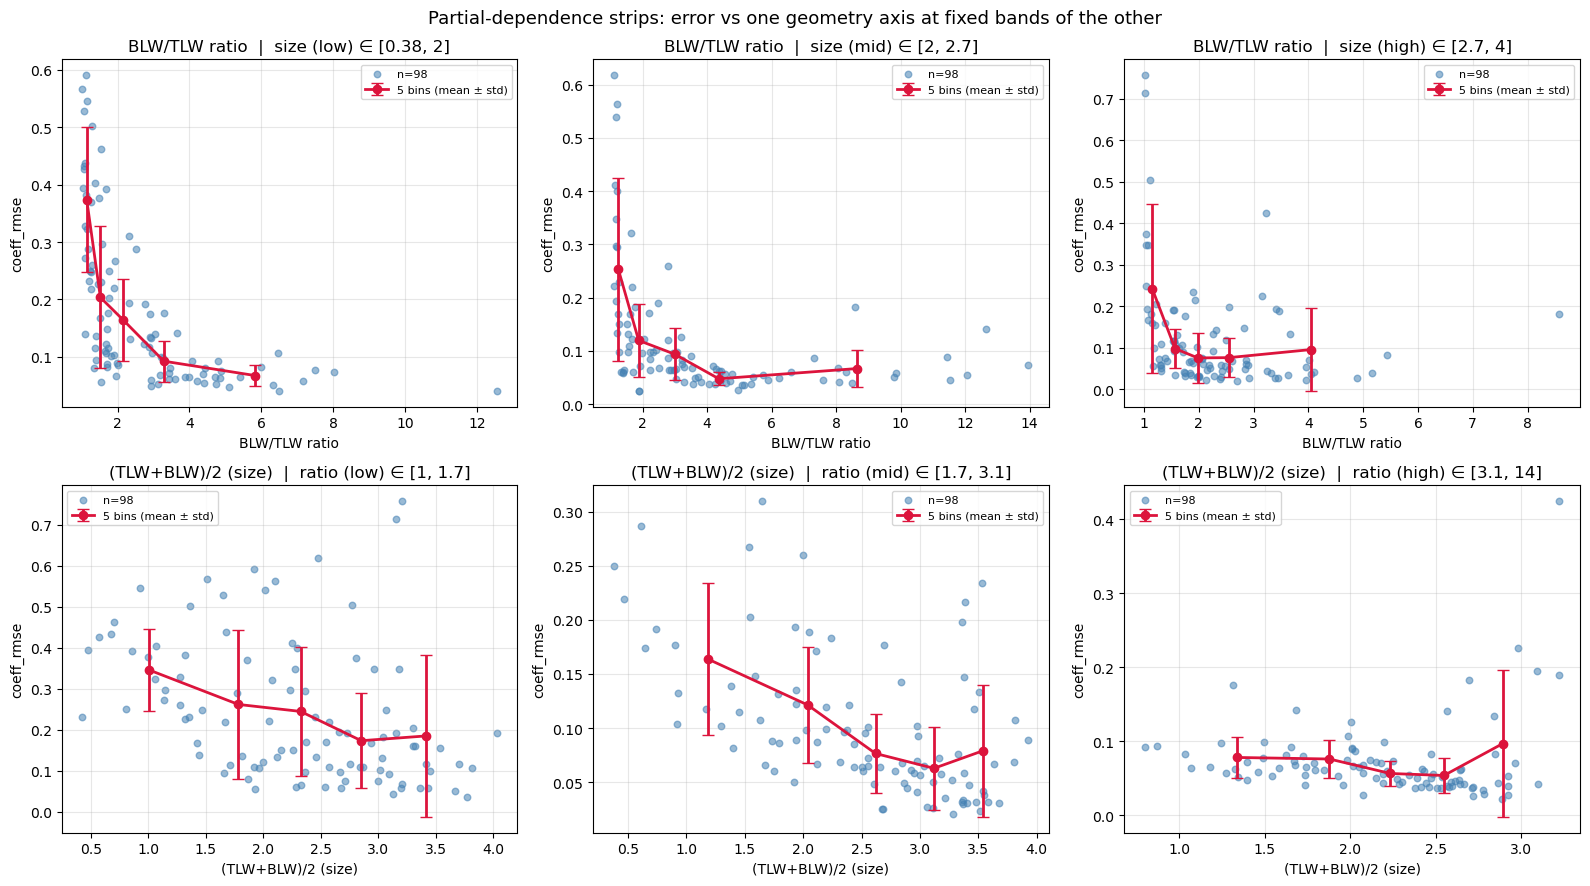

In [34]:
#### PARTIAL-DEPENDENCE STRIPS ####
# Hold one of (size, ratio) inside a narrow band and plot error vs the other.
# Separates the two effects more cleanly than the noisy bivariate heatmap.
def _strip(ax, x_full, y_full, hold_full, hold_lo, hold_hi, x_label, hold_label):
    sel = (hold_full >= hold_lo) & (hold_full <= hold_hi)
    if sel.sum() < 5:
        ax.set_visible(False)
        return
    x = x_full[sel]; y = y_full[sel]
    ax.scatter(x, y, alpha=0.55, s=22, color='steelblue', label=f'n={sel.sum()}')

    n_bins = min(5, max(2, sel.sum() // 8))
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    bid = np.digitize(x, edges[1:-1])
    cs, ms, ss = [], [], []
    for b in range(n_bins):
        m = bid == b
        if m.any():
            cs.append(x[m].mean()); ms.append(y[m].mean()); ss.append(y[m].std())
    ax.errorbar(cs, ms, yerr=ss, color='crimson', marker='o', linewidth=2, capsize=4,
                label=f'{n_bins} bins (mean ± std)')
    ax.set_xlabel(x_label)
    ax.set_ylabel('coeff_rmse')
    ax.set_title(f'{x_label}  |  {hold_label} ∈ [{hold_lo:.2g}, {hold_hi:.2g}]')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

size_arr  = diag_test['size'].values
ratio_arr = diag_test['ratio'].values
y_arr     = diag_test['coeff_rmse'].values

# 3 size bands (low/mid/high tertiles) with error vs ratio
size_terc  = np.quantile(size_arr,  [0, 1/3, 2/3, 1])
# 3 ratio bands (low/mid/high tertiles) with error vs size
ratio_terc = np.quantile(ratio_arr, [0, 1/3, 2/3, 1])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
band_names = ['low', 'mid', 'high']
for j, name in enumerate(band_names):
    _strip(axes[0, j], ratio_arr, y_arr, size_arr,
           size_terc[j],  size_terc[j+1],
           x_label='BLW/TLW ratio', hold_label=f'size ({name})')
    _strip(axes[1, j], size_arr, y_arr, ratio_arr,
           ratio_terc[j], ratio_terc[j+1],
           x_label='(TLW+BLW)/2 (size)', hold_label=f'ratio ({name})')
fig.suptitle('Partial-dependence strips: error vs one geometry axis at fixed bands of the other',
             fontsize=13)
fig.tight_layout()
plt.show()

In [ ]:
#### TRAIN-DENSITY-NORMALIZED ERROR HEATMAP ####
# mean coeff_rmse / log(1 + train_density) per (size, ratio) cell. Highlights
# cells where error is high *given* training coverage — closer to a true
# "model weakness" signal than raw mean error.
norm_err = mean_err / np.log1p(train_density)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
extent = [ratio_edges[0], ratio_edges[-1], size_edges[0], size_edges[-1]]

im0 = axes[0].imshow(mean_err, origin='lower', aspect='auto', extent=extent, cmap='magma')
axes[0].set_title('Mean coeff_rmse  (raw)')
fig.colorbar(im0, ax=axes[0], label='coeff_rmse')

im1 = axes[1].imshow(norm_err, origin='lower', aspect='auto', extent=extent, cmap='magma')
axes[1].set_title('coeff_rmse / log(1 + train_density)\n(weakness map)')
fig.colorbar(im1, ax=axes[1], label='normalized error')

for ax in axes:
    ax.set_xlabel('BLW/TLW ratio')
    ax.set_ylabel('(TLW+BLW)/2  (size)')

fig.suptitle('Raw vs density-normalized error', fontsize=13)
fig.tight_layout()
plt.show()

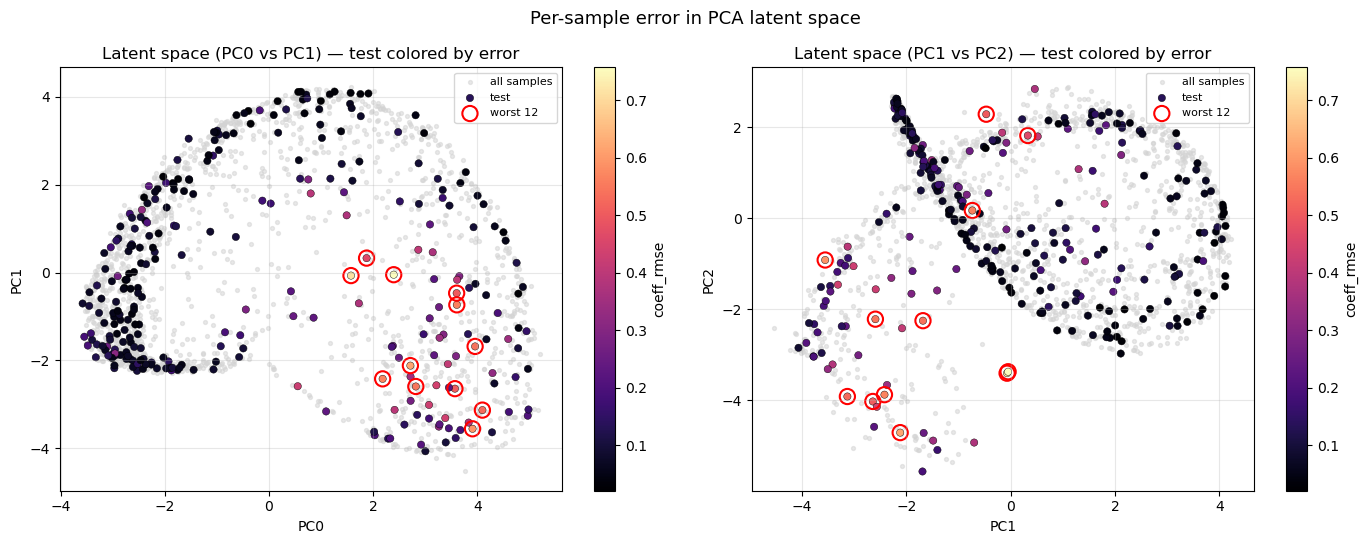

In [38]:
#### LATENT-SPACE ERROR OVERLAY ####
# PC0 vs PC1 of the TRUE features for all samples (train + test grey),
# test points colored by per-sample coeff_rmse, top-N worst circled.
# If high-error points cluster in latent space, that points at a different
# (and more actionable) failure mode than geometry-space clustering.
all_feat = data.feat.numpy()
test_feat = all_feat[test_idx_arr]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (i, j) in zip(axes, [(0, 1), (1, 2)]):
    ax.scatter(all_feat[:, i], all_feat[:, j], s=8, color='lightgrey',
               alpha=0.5, label='all samples')
    sc = ax.scatter(test_feat[:, i], test_feat[:, j],
                    c=diag_test['coeff_rmse'].values,
                    cmap='magma', s=28, edgecolor='k', linewidth=0.3,
                    label='test')
    ax.scatter(test_feat[worst_local, i], test_feat[worst_local, j],
               s=120, facecolors='none', edgecolor='red', linewidth=1.5,
               label=f'worst {N_WORST}')
    fig.colorbar(sc, ax=ax, label='coeff_rmse')
    ax.set_xlabel(f'PC{i}')
    ax.set_ylabel(f'PC{j}')
    ax.set_title(f'Latent space (PC{i} vs PC{j}) — test colored by error')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')

fig.suptitle('Per-sample error in PCA latent space', fontsize=13)
fig.tight_layout()
plt.show()

C:\Users\robert\AppData\Local\Temp\ipykernel_30748\3184554801.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


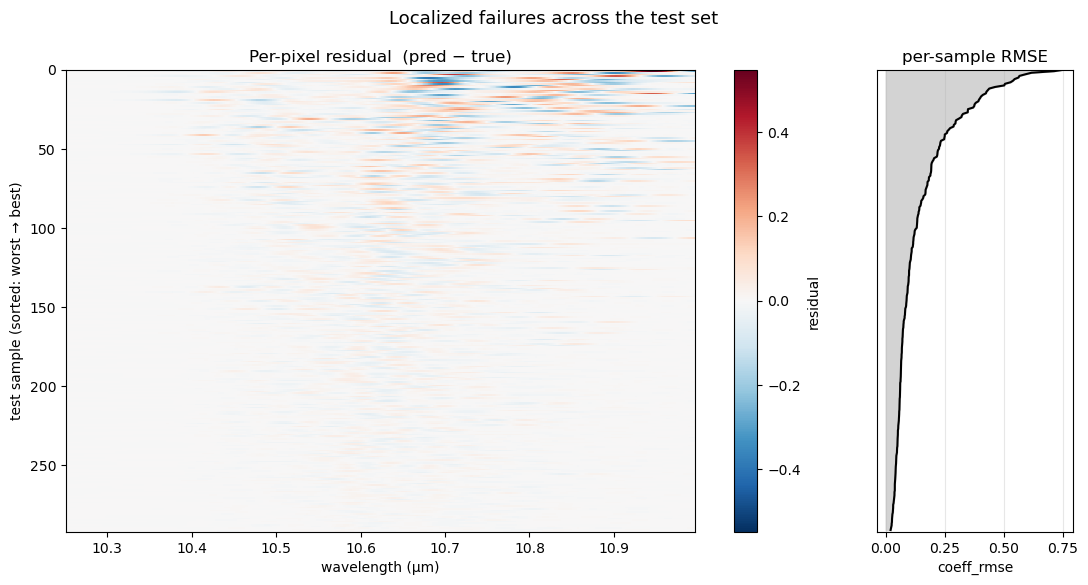

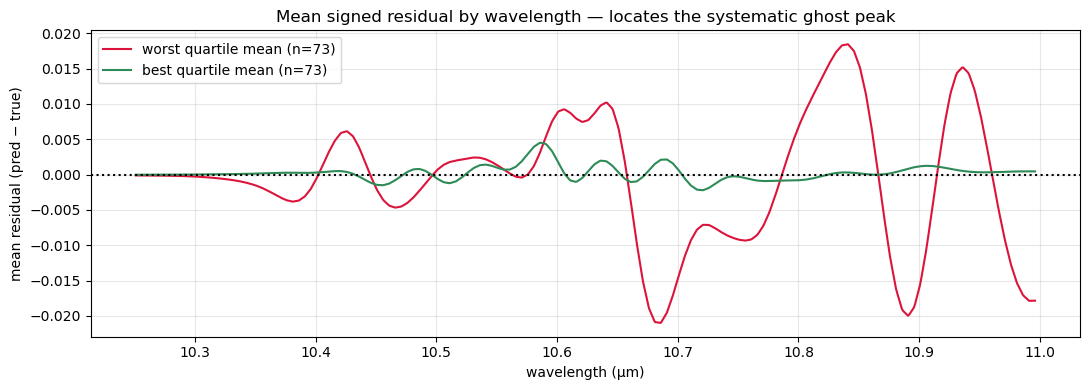

In [37]:
#### PER-PIXEL RESIDUAL HEATMAP ####
# Rows = test samples sorted by coeff_rmse (worst at top), cols = wavelength,
# color = pred - true reconstructed spectrum. Localizes the failure: if the
# ghost-peak is real, every bad row should light up in the same wavelength band.
resid_test = (pred_spec_t - true_spec_t).numpy()  # (N_test, n_wl)
order_desc = np.argsort(diag_test['coeff_rmse'].values)[::-1]
resid_sorted = resid_test[order_desc]
rmse_sorted  = diag_test['coeff_rmse'].values[order_desc]

vmax = np.abs(resid_sorted).max()
fig, axes = plt.subplots(1, 2, figsize=(13, 6),
                         gridspec_kw={'width_ratios': [4, 1], 'wspace': 0.05})
ax_h, ax_r = axes
extent = [wl_plot.min(), wl_plot.max(), len(resid_sorted), 0]
im = ax_h.imshow(resid_sorted, aspect='auto', extent=extent,
                 cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
ax_h.set_xlabel('wavelength (µm)')
ax_h.set_ylabel('test sample (sorted: worst → best)')
ax_h.set_title('Per-pixel residual  (pred − true)')
fig.colorbar(im, ax=ax_h, label='residual')

ax_r.plot(rmse_sorted, np.arange(len(rmse_sorted)), color='k')
ax_r.fill_betweenx(np.arange(len(rmse_sorted)), 0, rmse_sorted, color='lightgrey')
ax_r.set_ylim(ax_h.get_ylim())
ax_r.set_xlabel('coeff_rmse')
ax_r.set_yticks([])
ax_r.set_title('per-sample RMSE')
ax_r.grid(alpha=0.3)

fig.suptitle('Localized failures across the test set', fontsize=13)
fig.tight_layout()
plt.show()

# Mean residual per pixel restricted to worst quartile vs best quartile
worst_mean_resid = resid_test[worst_mask].mean(axis=0)
best_mean_resid  = resid_test[best_mask].mean(axis=0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wl_plot, worst_mean_resid, color='crimson', label=f'worst quartile mean (n={worst_mask.sum()})')
ax.plot(wl_plot, best_mean_resid,  color='seagreen', label=f'best quartile mean (n={best_mask.sum()})')
ax.axhline(0, color='k', linestyle=':')
ax.set_xlabel('wavelength (µm)')
ax.set_ylabel('mean residual (pred − true)')
ax.set_title('Mean signed residual by wavelength — locates the systematic ghost peak')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

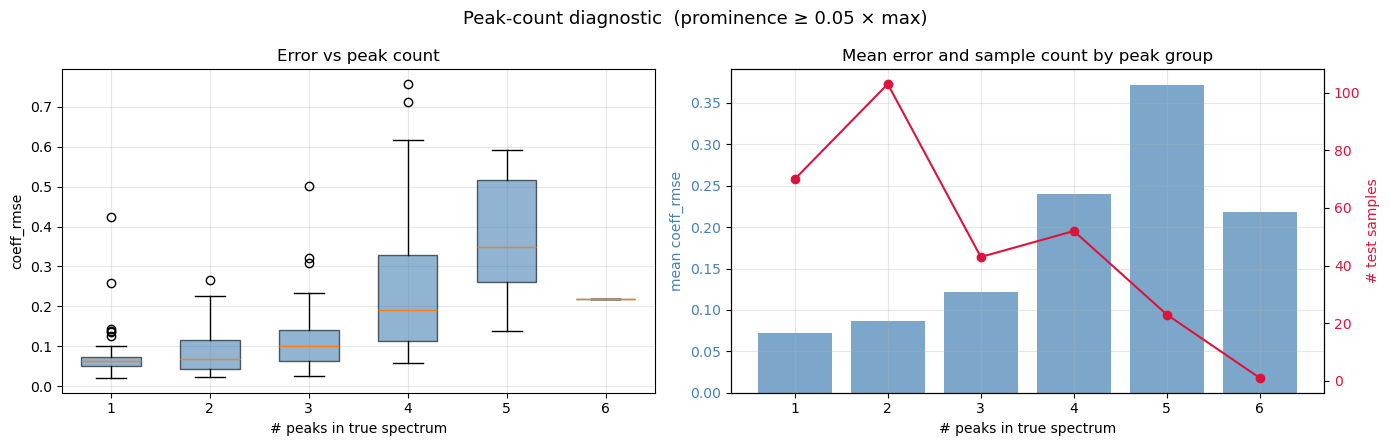


Spearman(n_peaks, coeff_rmse) = +0.606  (p=1.26e-30)
  1 peaks: mean coeff_rmse = 0.0721   (n=70)
  2 peaks: mean coeff_rmse = 0.0866   (n=103)
  3 peaks: mean coeff_rmse = 0.1222   (n=43)
  4 peaks: mean coeff_rmse = 0.2404   (n=52)
  5 peaks: mean coeff_rmse = 0.3720   (n=23)
  6 peaks: mean coeff_rmse = 0.2183   (n=1)


In [36]:
#### PEAK-COUNT DIAGNOSTIC ####
# Count peaks in the true spectrum per test sample and bin error by peak count.
# Tests the hypothesis that multi-peak shapes are the failure mode.
from scipy.signal import find_peaks

PROMINENCE = 0.05  # fraction of max
true_spec_np = true_spec_t.numpy()
peak_counts = np.array([
    len(find_peaks(s, prominence=PROMINENCE * s.max())[0])
    for s in true_spec_np
])

diag_test['n_peaks'] = peak_counts

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
unique_counts = np.sort(np.unique(peak_counts))

# Boxplot of coeff_rmse by peak count
groups = [diag_test.loc[peak_counts == c, 'coeff_rmse'].values for c in unique_counts]
bp = axes[0].boxplot(groups, positions=unique_counts, widths=0.6,
                     patch_artist=True, showfliers=True)
for box in bp['boxes']:
    box.set_facecolor('steelblue'); box.set_alpha(0.6)
axes[0].set_xlabel('# peaks in true spectrum')
axes[0].set_ylabel('coeff_rmse')
axes[0].set_title('Error vs peak count')
axes[0].grid(alpha=0.3)

# Mean error and sample count per peak group
means = np.array([g.mean() if g.size else np.nan for g in groups])
counts_n = np.array([g.size for g in groups])
ax_b = axes[1]
ax_b.bar(unique_counts, means, color='steelblue', alpha=0.7, label='mean coeff_rmse')
ax_b.set_xlabel('# peaks in true spectrum')
ax_b.set_ylabel('mean coeff_rmse', color='steelblue')
ax_b.tick_params(axis='y', labelcolor='steelblue')
ax_b.grid(alpha=0.3)
ax_b2 = ax_b.twinx()
ax_b2.plot(unique_counts, counts_n, color='crimson', marker='o', label='# test samples')
ax_b2.set_ylabel('# test samples', color='crimson')
ax_b2.tick_params(axis='y', labelcolor='crimson')
ax_b.set_title('Mean error and sample count by peak group')

fig.suptitle(f'Peak-count diagnostic  (prominence ≥ {PROMINENCE} × max)', fontsize=13)
fig.tight_layout()
plt.show()

# Spearman of n_peaks vs coeff_rmse
sr_pk, sp_pk = spearmanr(peak_counts, diag_test['coeff_rmse'].values)
print(f"\nSpearman(n_peaks, coeff_rmse) = {sr_pk:+.3f}  (p={sp_pk:.2e})")
for c, m, n in zip(unique_counts, means, counts_n):
    print(f"  {c} peaks: mean coeff_rmse = {m:.4f}   (n={n})")

NameError: name 'all_feat' is not defined

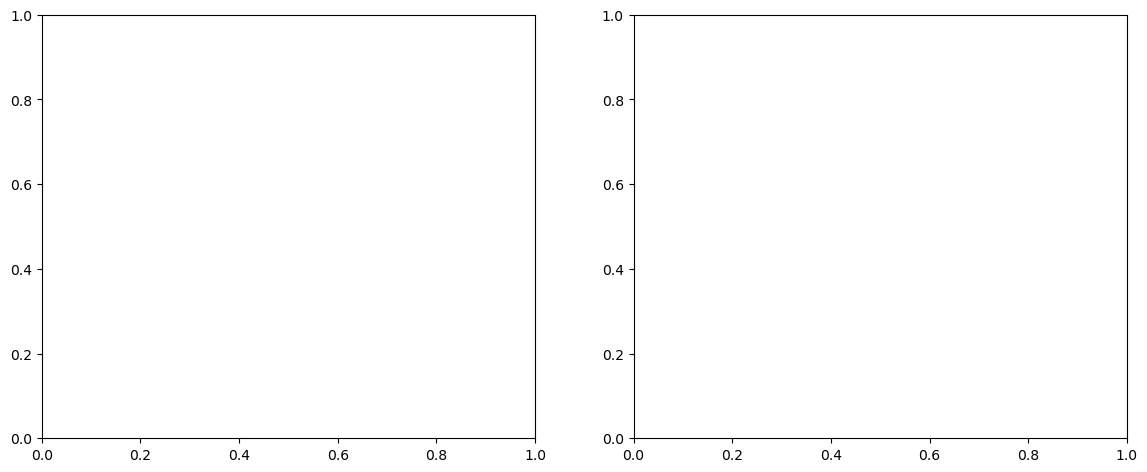

In [35]:
#### LATENT SPACE COLORED BY PEAK COUNT ####
# Re-run the latent-space scatter colored by n_peaks instead of error.
# Confirms (or refutes) that worst-N occupy the multi-peak region of latent space.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (i, j) in zip(axes, [(0, 1), (1, 2)]):
    ax.scatter(all_feat[:, i], all_feat[:, j], s=8, color='lightgrey',
               alpha=0.5, label='all samples')
    sc = ax.scatter(test_feat[:, i], test_feat[:, j],
                    c=peak_counts, cmap='viridis', s=28,
                    edgecolor='k', linewidth=0.3, label='test')
    ax.scatter(test_feat[worst_local, i], test_feat[worst_local, j],
               s=120, facecolors='none', edgecolor='red', linewidth=1.5,
               label=f'worst {N_WORST}')
    fig.colorbar(sc, ax=ax, label='# peaks')
    ax.set_xlabel(f'PC{i}')
    ax.set_ylabel(f'PC{j}')
    ax.set_title(f'Latent space (PC{i} vs PC{j}) — test colored by peak count')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')
fig.suptitle('Peak count in PCA latent space', fontsize=13)
fig.tight_layout()
plt.show()

In [ ]:
#### (h, s) HEATMAP RESTRICTED TO SMALL-BLW REGIME ####
# h and s have ~0 marginal correlation, but they may matter inside the bad
# (small blw) band. Restrict to the lower tertile of blw and show mean error
# over (h, s).
BLW_THRESH = np.quantile(diag_test['blw'].values, 1/3)
sub = diag_test[diag_test['blw'].values <= BLW_THRESH].copy()
geom_sub = geom_test[diag_test['blw'].values <= BLW_THRESH].copy()
print(f"Restricting to blw <= {BLW_THRESH:.3g} ({len(sub)} test samples).")

if len(sub) >= 10:
    n_b = 4
    h_edges = np.quantile(geom_sub['h'].values, np.linspace(0, 1, n_b + 1))
    s_edges = np.quantile(geom_sub['s'].values, np.linspace(0, 1, n_b + 1))
    h_edges[-1] += 1e-9; s_edges[-1] += 1e-9

    err_sum, _, _ = np.histogram2d(geom_sub['h'].values, geom_sub['s'].values,
                                   bins=[h_edges, s_edges],
                                   weights=sub['coeff_rmse'].values)
    cnt, _, _ = np.histogram2d(geom_sub['h'].values, geom_sub['s'].values,
                               bins=[h_edges, s_edges])
    mean_err_hs = np.where(cnt > 0, err_sum / np.maximum(cnt, 1), np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    extent = [s_edges[0], s_edges[-1], h_edges[0], h_edges[-1]]
    im0 = axes[0].imshow(mean_err_hs, origin='lower', aspect='auto',
                         extent=extent, cmap='magma')
    axes[0].set_title(f'Mean coeff_rmse  |  blw ≤ {BLW_THRESH:.2g}')
    fig.colorbar(im0, ax=axes[0], label='coeff_rmse')

    im1 = axes[1].imshow(cnt, origin='lower', aspect='auto',
                         extent=extent, cmap='Blues')
    axes[1].set_title('Test count per cell')
    fig.colorbar(im1, ax=axes[1], label='# samples')

    for ax in axes:
        ax.set_xlabel('s')
        ax.set_ylabel('h')
    fig.suptitle('Within the bad-blw band: does (h, s) explain residual variance?',
                 fontsize=13)
    fig.tight_layout()
    plt.show()

    # Spearman within the band
    sr_h, _ = spearmanr(geom_sub['h'].values, sub['coeff_rmse'].values)
    sr_s, _ = spearmanr(geom_sub['s'].values, sub['coeff_rmse'].values)
    print(f"Within blw <= {BLW_THRESH:.3g}:  Spearman(h, rmse)={sr_h:+.3f}  "
          f"Spearman(s, rmse)={sr_s:+.3f}")
else:
    print("Not enough samples in the small-blw band for a heatmap.")

In [ ]:
#### CV-FOLD DISAGREEMENT (EPISTEMIC PROXY) ####
# Std across the 4 fold-model coeff predictions per test sample. If samples the
# folds disagree on are also the ones with high error, disagreement is a free
# OOD / active-learning signal.
with torch.no_grad():
    fold_preds = torch.stack([m(geom_t) for m in fold_models])  # (n_folds, N, K)
fold_std = fold_preds.std(dim=0).mean(dim=1).numpy()  # mean std across PCs per sample

pr_d, pp_d = pearsonr(fold_std, diag_test['coeff_rmse'].values)
sr_d, sp_d = spearmanr(fold_std, diag_test['coeff_rmse'].values)
print(f"Pearson(fold_std, coeff_rmse) = {pr_d:+.3f} (p={pp_d:.2e})")
print(f"Spearman                       = {sr_d:+.3f} (p={sp_d:.2e})")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(fold_std, diag_test['coeff_rmse'].values, alpha=0.5, s=22, color='steelblue')
ax.scatter(fold_std[worst_local], diag_test['coeff_rmse'].values[worst_local],
           s=120, facecolors='none', edgecolor='red', linewidth=1.5,
           label=f'worst {N_WORST}')
# y = x reference
mx = max(fold_std.max(), diag_test['coeff_rmse'].max())
ax.plot([0, mx], [0, mx], color='k', linestyle=':', alpha=0.5, label='y = x')
ax.set_xlabel('mean across-fold std (epistemic proxy)')
ax.set_ylabel('coeff_rmse')
ax.set_title(f'Fold disagreement vs error\nPearson={pr_d:+.2f}  Spearman={sr_d:+.2f}')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
#### K-SWEEP: WORST QUARTILE vs ALL  (PCA basis fidelity) ####
# Reconstruct each test spectrum from only the first K' coefficients of its
# TRUE PCA features (no MLP) and compare to the raw absorption. This isolates
# PCA-basis truncation error. If worst-quartile recon error >> all-test recon
# error, the basis itself fails on those geometries → invest in a richer
# representation (more PCs, wavelets, MaxPeak features). If it's similar,
# the basis is fine and the MLP is the bottleneck → invest in the predictor.
raw_test = _raw_abs[test_idx_arr]  # (N_test, n_wl)
K_max = feat_t.shape[1]
K_grid = sorted(set([k for k in [2, 5, 10, 15, 20, K_max] if k <= K_max]))

mse_all = []
mse_worst = []
mse_best = []
for K_try in K_grid:
    coeffs_trunc = feat_t.clone()
    coeffs_trunc[:, K_try:] = 0
    recon = data.reconstruct_spectrum(coeffs_trunc).numpy()  # (N_test, n_wl)
    sq = (recon - raw_test) ** 2
    mse_per_sample = sq.mean(axis=1)
    mse_all.append(mse_per_sample.mean())
    mse_worst.append(mse_per_sample[worst_mask].mean())
    mse_best.append(mse_per_sample[best_mask].mean())

# MLP-induced error at the trained K (current test recon error vs raw)
mlp_err_all   = ((pred_spec_t.numpy() - raw_test) ** 2).mean(axis=1).mean()
mlp_err_worst = ((pred_spec_t.numpy() - raw_test) ** 2).mean(axis=1)[worst_mask].mean()
mlp_err_best  = ((pred_spec_t.numpy() - raw_test) ** 2).mean(axis=1)[best_mask].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(K_grid, mse_all,   color='k',        marker='o', label='all test  (PCA only)')
ax.plot(K_grid, mse_worst, color='crimson',  marker='o', label='worst quartile  (PCA only)')
ax.plot(K_grid, mse_best,  color='seagreen', marker='o', label='best quartile  (PCA only)')
ax.axhline(mlp_err_all,   color='k',        linestyle='--', alpha=0.6, label='MLP @ K=25  (all test)')
ax.axhline(mlp_err_worst, color='crimson',  linestyle='--', alpha=0.6, label='MLP @ K=25  (worst quartile)')
ax.axhline(mlp_err_best,  color='seagreen', linestyle='--', alpha=0.6, label='MLP @ K=25  (best quartile)')
ax.set_yscale('log')
ax.set_xlabel('K (# PCA components retained)')
ax.set_ylabel('reconstruction MSE vs raw spectrum')
ax.set_title('PCA basis fidelity vs MLP error\n'
             '(gap between solid worst-line at K=25 and dashed worst-line = MLP-induced error)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=8, loc='best')
fig.tight_layout()
plt.show()

print("\nAt K=25:")
print(f"  PCA-only recon MSE  -- all: {mse_all[-1]:.5f}   "
      f"worst Q: {mse_worst[-1]:.5f}   best Q: {mse_best[-1]:.5f}")
print(f"  MLP recon MSE       -- all: {mlp_err_all:.5f}   "
      f"worst Q: {mlp_err_worst:.5f}   best Q: {mlp_err_best:.5f}")
print(f"  MLP-induced share (worst Q): "
      f"{(mlp_err_worst - mse_worst[-1]) / max(mlp_err_worst, 1e-12) * 100:.1f}% of total error")